[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/danpele/MFM/blob/main/Quantlets/Ch_00/MFM_ch0_seminar/MFM_ch0_seminar.ipynb)

# Seminar 0: Financial Markets in 2026 — Hands-on

**Modelling Financial Markets (MFM)**, Master's programme *Applied Statistics and Data Science*, Bucharest University of Economic Studies

*Daniel Traian Pele, Antoaneta Amza*

> Quantlet `MFM_ch0_seminar`: student version of the Seminar 0 notebook. Solved exercises (A1, A2, A4, A7, A8, B1, B2, B2 Extended, B6, B7) are shown with code and output; the proposed exercises (A5, A6, A9, A10, A11, A12, B1 Extended, B3, B4, B5, B5 Extended, B6 Extended, B8, B9, B9 Extended, B10, B10 Extended, C1, C2, C3) are not solved here (an empty code cell where they need code).

Exercises of Seminar 0, in the order of the seminar slides ([student slides](https://danpele.github.io/MFM/EN/Seminars/seminar0_financial_markets.pdf)). The seminar comes before the Chapter 0 lecture: every notion of the core is defined in its task.

- **Core** (in class): [Setup check](#setup), [A1–A4](#A1), [B1](#B1), [B2](#B2)
- **Your turn** (in class): [A5](#A5), [A6](#A6)
- **Homework**: [B3](#B3), [B4](#B4), [B5](#B5), [C1](#C1)
- **After the lecture (optional)**, each pack in its dependency order: [Pack 1](#pack1) (B1 full audit, B2 six assets, B6), [Pack 2](#pack2) (A7, B2 extended), [Pack 3](#pack3) (A8, A9, A10), [Pack 4](#pack4) (B6 extended, A11, A12, C2), [Pack 5](#pack5) (B5 extended), [Pack 6](#pack6) (B7, B8, B9, B9 extended, B1 extended), [Pack 7](#pack7) (B10, B10 extended), [Pack 8](#pack8) (C3)

**[Solved]** exercises show the full code and results: use them as models. **[Proposed]** exercises have an empty cell: write your code (or your answer) there. The functions that read the data, and the helper functions, are provided. Every bootstrap exercise creates its own generator `numpy.random.default_rng(42)`, so its numbers do not depend on which cells you ran before.

## Setup <a id="setup"></a>

> **Working in Google Colab? Save your own copy first.**
> The Colab link opens a temporary copy: when you close the tab or the session times out, your changes are lost.
> Use **File → Save a copy in Drive** (it goes to the *Colab Notebooks* folder of your ASE Google Drive) and work in that copy.
> For the team project, **File → Save a copy in GitHub** puts the notebook directly in your team's repository.
> Files you create while the notebook runs (CSV, charts) are also temporary: set `SAVE_TO_DRIVE = True` in the next cell to keep them.

In [ ]:
# Optional (Colab only): keep the files you create in Google Drive
SAVE_TO_DRIVE = False   # set to True, run this cell and allow access to your Drive

import os
OUT_DIR = '.'
if SAVE_TO_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    OUT_DIR = '/content/drive/MyDrive/MFM/Chapter_0'
    os.makedirs(OUT_DIR, exist_ok=True)
print('Save your outputs to:', os.path.abspath(OUT_DIR))


In [1]:
import os
import io
import json
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Chart style: transparent background, legend below the plot
plt.rcParams['figure.facecolor'] = 'none'
plt.rcParams['axes.facecolor'] = 'none'
plt.rcParams['savefig.facecolor'] = 'none'
plt.rcParams['savefig.transparent'] = True
plt.rcParams['axes.grid'] = False
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']
plt.rcParams['font.size'] = 9
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['axes.titlesize'] = 11
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.linewidth'] = 0.6
plt.rcParams['lines.linewidth'] = 1.1
plt.rcParams['legend.facecolor'] = 'none'
plt.rcParams['legend.framealpha'] = 0
plt.rcParams['legend.fontsize'] = 8

# Chart colours
MainBlue = '#1A3A6E'
IDAred   = '#CD0000'
Forest   = '#2E7D32'
Amber    = '#B5853F'
Orange   = '#E67E22'
Purple   = '#8E44AD'
Crimson  = '#DC3545'
Navy     = '#1F2A44'   # reference lines (no grey in charts)
BandBlue = '#C5D2E8'   # light MainBlue tint for confidence / reference bands
Gray, LightGray = Navy, BandBlue   # legacy names kept for importing scripts
Teal     = '#17A2B8'


def save_fig(name):
    """Show the chart inline"""
    plt.show()
    plt.close()


def legend_outside_bottom(ax, ncol=2, y=-0.22):
    """Place the legend outside the plot, bottom centre."""
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False)


def bottom_legend(fig, ncol=3, handles=None, labels=None, fontsize=8):
    """Legend below the figure (outside the axes), after tight_layout; save_fig keeps it (bbox_inches='tight')."""
    plt.tight_layout()
    if handles is None:
        handles, labels, seen = [], [], set()
        for ax in fig.axes:
            for h, l in zip(*ax.get_legend_handles_labels()):
                if l not in seen and not l.startswith('_'):
                    handles.append(h); labels.append(l); seen.add(l)
    fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.0), ncol=ncol, frameon=False, fontsize=fontsize)


def log_axis(ax, ticks):
    """Log axis with readable labels (no scientific notation)."""
    ax.set_yscale('log')
    ax.set_yticks(ticks)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:g}'))
    ax.yaxis.set_minor_formatter(plt.NullFormatter())

In [3]:
REPO_RAW = 'https://raw.githubusercontent.com/danpele/MFM/main/data/market/'
LOCAL_DIRS = ['../../data/market', '../data/market', 'data/market']   # cloned repository
START, END = '2000-01-01', '2026-09-18'

# name -> (source, symbol, field)
SERIES = {
    'S&P 500': ('market', 'GSPC.INDX', 'close'),
    'Euro Stoxx 50': ('market', 'STOXX50E.INDX', 'close'),
    'Nikkei 225': ('market', 'N225.INDX', 'close'),
    'VIX': ('market', 'VIX.INDX', 'close'),
    'BET-TR': ('market', 'BETTR.INDX', 'close'),
    'BET': ('market', 'BET', 'close'),
    'BET-XT': ('market', 'BETXT.INDX', 'close'),
    'US Treasuries 20y+ (TLT)': ('market', 'TLT.US', 'adjusted_close'),
    'SPY': ('market', 'SPY.US', 'adjusted_close'),
    'RSP': ('market', 'RSP.US', 'adjusted_close'),
    'IBIT': ('market', 'IBIT.US', 'close'),
    'IBIT volume': ('market', 'IBIT.US', 'volume'),
    'Gold': ('market', 'XAUUSD.FOREX', 'close'),
    'EUR/USD': ('market', 'EURUSD.FOREX', 'close'),
    'EUR/RON (market)': ('market', 'EURRON.FOREX', 'close'),
    'Bitcoin': ('market', 'BTC-USD.CC', 'close'),
    'Ethereum': ('market', 'ETH-USD.CC', 'close'),
    'Tether (USDT)': ('market', 'USDT-USD.CC', 'close'),
    'Romania 10y': ('market', 'RO10Y.GBOND', 'close'),
    'Germany 10y': ('market', 'DE10Y.GBOND', 'close'),
    'Banca Transilvania': ('market', 'TLV.RO', 'adjusted_close'),
    'OMV Petrom': ('market', 'SNP.RO', 'adjusted_close'),
    'BRD': ('market', 'BRD.RO', 'adjusted_close'),
    'Transgaz': ('market', 'TGN.RO', 'adjusted_close'),
    'Romgaz': ('market', 'SNG.RO', 'adjusted_close'),
    'Hidroelectrica': ('market', 'H2O.RO', 'adjusted_close'),
    'EUR/RON': ('bnr', 'EUR', None),
    'DGS10': ('fred', 'DGS10', None),
    'DGS2': ('fred', 'DGS2', None),
    'FEDFUNDS': ('fred', 'FEDFUNDS', None),
    'USD per EUR': ('fred', 'DEXUSEU', None),
    'JPY per USD': ('fred', 'DEXJPUS', None),
    'T10Y2Y': ('fred', 'T10Y2Y', None),
    'ETF equities': ('fred', 'BOGZ1LM563064100Q', None),
    'All equities': ('fred', 'BOGZ1LM893064105Q', None),
    'Stablecoins': ('defillama', 'stablecoincharts/all', None),
}


def read_market(symbol):
    """Daily market series: local copy if the repository is cloned, otherwise GitHub"""
    for d in LOCAL_DIRS:
        path = os.path.join(d, f'{symbol}.csv')
        if os.path.exists(path):
            return pd.read_csv(path, index_col='date', parse_dates=True)
    return pd.read_csv(REPO_RAW + f'{symbol}.csv', index_col='date', parse_dates=True)


def fetch_daily(symbol, source='market', field='close', start=START, end=END):
    """Single access point to the data: returns a daily pd.Series (no NaN)."""
    if source == 'market':
        s = read_market(symbol)[field]
    elif source == 'fred':
        raw = urllib.request.urlopen(
            f'https://fred.stlouisfed.org/graph/fredgraph.csv?id={symbol}', timeout=90).read().decode()
        s = pd.read_csv(io.StringIO(raw), index_col=0, parse_dates=True, na_values='.').iloc[:, 0]
    elif source == 'defillama':
        req = urllib.request.Request(f'https://stablecoins.llama.fi/{symbol}',
                                     headers={'User-Agent': 'Mozilla/5.0'})
        d = json.load(urllib.request.urlopen(req, timeout=90))
        s = pd.Series({pd.to_datetime(int(x['date']), unit='s'): x['totalCirculatingUSD'].get('peggedUSD', 0)
                       for x in d}) / 1e9                                   # billion USD
    elif source == 'bnr':
        # official BNR rate (RON per unit of currency), yearly XML archives
        import re
        rows = []
        for y in range(max(int(start[:4]), 2005), int(end[:4]) + 1):
            url = f'https://curs.bnr.ro/files/xml/years/nbrfxrates{y}.xml'
            xml = urllib.request.urlopen(urllib.request.Request(url, headers={'User-Agent': 'Mozilla'}),
                                         timeout=90).read().decode()
            for d, body in re.findall(r'<Cube date="([\d-]+)">(.*?)</Cube>', xml, re.S):
                m = re.search(rf'<Rate currency="{symbol}">([\d.]+)</Rate>', body)
                if m:
                    rows.append((d, float(m.group(1))))
        s = pd.Series(dict(rows))
    else:
        raise ValueError(f'unknown source: {source}')
    s = pd.to_numeric(s, errors='coerce')
    s.index = pd.to_datetime(s.index)
    s.index.name = 'Date'
    return s.sort_index().loc[start:end].dropna()


WEEKDAYS_ONLY = {'EUR/USD', 'Gold'}   # FX/OTC quotes: weekend quotes break the Friday-Monday return


def load(name, start=START, end=END):
    """The series named in SERIES (gold and EUR/USD: weekdays only)."""
    source, symbol, field = SERIES[name]
    s = fetch_daily(symbol, source, field, start, end).rename(name)
    if name in WEEKDAYS_ONLY:
        s = s[s.index.dayofweek < 5]
    return s


def load_panel(names, start=START, end=END):
    """Several series aligned on date (NaN where a market does not trade)."""
    return pd.concat([load(n, start, end) for n in names], axis=1)

In [4]:
def clean_series(y, max_dev=1.0, window=11):
    """Drop weekend rows and points more than max_dev from the centred rolling median."""
    y = y[y.index.dayofweek < 5]
    med = y.rolling(window, center=True, min_periods=3).median()
    return y[(y - med).abs() <= max_dev]


def drawdown(p):
    """Drawdown from the previous peak: P_t / max_{s<=t} P_s - 1."""
    return p / p.cummax() - 1


def ann_stats(p, periods=252):
    """Annualised return (CAGR) and annualised volatility from daily prices.

    periods='obs' uses the observed number of observations per year of the series.
    """
    p = p.dropna()
    years = (p.index[-1] - p.index[0]).days / 365.25
    cagr = (p.iloc[-1] / p.iloc[0]) ** (1 / years) - 1
    r = np.log(p).diff().dropna()
    if periods == 'obs':
        periods = len(r) / years
    return cagr, r.std() * np.sqrt(periods)


def to_usd(local, fx, invert=False):
    """Convert a local-currency index to USD with the FRED rate of the same day
    (the last available rate, at most 5 days back, if the day is missing)."""
    f = fx.dropna().reindex(local.index, method='ffill', tolerance=pd.Timedelta(days=5))
    return (local / f if invert else local * f).dropna()

In [5]:
def sb_index(n, mean_block, rng):
    """Stationary bootstrap (Politis and Romano, 1994): blocks of random, geometric length with mean mean_block, wrapped around."""
    idx = np.empty(n, dtype=int); i = rng.integers(n)
    for t in range(n):
        i = rng.integers(n) if (t == 0 or rng.random() < 1 / mean_block) else (i + 1) % n
        idx[t] = i
    return idx


def obs_per_year(p):
    """Observed return intervals per year q = n / Y: n returns, Y = calendar days between first and last price / 365.25."""
    return (len(p) - 1) / ((p.index[-1] - p.index[0]).days / 365.25)


def sharpe(R, q):
    """Annualised Sharpe ratio, r_f = 0: sample mean / sample sd (divisor n - 1) of simple returns R, times sqrt(q)."""
    return R.mean() / R.std(ddof=1) * np.sqrt(q)


def se_lo(R, q):
    """Lo (2002), iid Normal returns, asymptotic: SE of the annualised Sharpe from T daily returns, sqrt(q (1 + SR_d^2/2) / T)."""
    sr_d = R.mean() / R.std(ddof=1)
    return np.sqrt(q * (1 + sr_d ** 2 / 2) / len(R))


def se_opdyke(R, q):
    """Opdyke (2007): asymptotic SE of the annualised Sharpe corrected for the skewness and kurtosis of daily returns."""
    from scipy import stats
    sr = R.mean() / R.std(ddof=1); g3 = stats.skew(R); g4 = stats.kurtosis(R, fisher=False)
    return np.sqrt((1 + sr ** 2 / 2 - g3 * sr + (g4 - 3) / 4 * sr ** 2) / len(R)) * np.sqrt(q)

**Setup check.** `load(name, start)` reads one daily series by its name (the dictionary `SERIES` lists every name and its price field). The SPY adjusted close from 2 Jan 2015 must have 2,945 prices, from 2 Jan 2015 to 18 Sep 2026; the first adjusted close is 169.26 and the close 205.43 (dividends are in the adjusted close only). The BNR EUR/RON rate has 2,939 values and the EUR/RON series from EODHD 3,115 from 1 Jan 2015. If your output differs, stop and check the name and the start date.

In [6]:
spy = load('SPY', start='2015-01-02')
bnr = load('EUR/RON', start='2015-01-01')
mkt = load('EUR/RON (market)', start='2015-01-01')
print(len(spy), spy.index[0].date(), spy.index[-1].date())
print(len(bnr), len(mkt))
print(read_market('SPY.US').loc['2015-01-02':'2015-01-06', ['close', 'adjusted_close']].round(2))

2945 2015-01-02 2026-09-18
2939 3115
             close  adjusted_close
date                              
2015-01-02  205.43          169.26
2015-01-05  201.76          166.24
2015-01-06  199.82          164.64


## Core (in class)

### A1–A4 [Solved]. Returns, annualisation, CAGR and drawdown <a id="A1"></a>

**A1.** Prices $P_0 = 100$, $P_1 = 110$, $P_2 = 99$. (1) Compute the simple returns $R_1, R_2$ and the log returns $r_1, r_2$. (2) Add the two simple returns and the two log returns. (3) Compute the two-period returns $P_2/P_0 - 1$ and $\ln(P_2/P_0)$ and compare them with the sums. **Report:** a table date / price / simple return / log return and one sentence on which returns add up.

**A2.** Daily volatility $\sigma_d = 1\%$: (1) annualise with $q = 252$ (equity index) and $q = 365$ (Bitcoin); (2) state the two assumptions under which $\sqrt{q}$ scaling is exact.

**A3.** The S&P 500 price index was multiplied by 3.72 between 2 Jan 2015 and 18 Sep 2026 (4,277 calendar days): (3) compute $Y = 4277/365.25$ and the CAGR $= 3.72^{1/Y} - 1$; (4) explain why it is lower than SPY's 13.7% in B2.

**A4.** Prices on days 0–5: 100, 120, 90, 110, 130, 100. (1) Running peak $M_t = \max_{s \le t} P_s$. (2) Drawdown $DD_t = P_t/M_t - 1$. (3) Maximum drawdown $\min_t DD_t$ and its day. **Report:** the completed table and the maximum drawdown.

In [7]:
P = np.array([100, 110, 99]); R = P[1:] / P[:-1] - 1; r = np.log(P[1:] / P[:-1])
print(pd.DataFrame({'price': P, 'simple return': np.r_[np.nan, R], 'log return': np.r_[np.nan, r]}).round(4))
print(f'A1: sum of simple returns {R.sum():+.4f}, compounded {(1 + R).prod() - 1:+.4f}; sum of log returns {r.sum():+.5f} = ln(0.99) {np.log(0.99):+.5f}')
print('A2:', round(0.01 * np.sqrt(252), 4), round(0.01 * np.sqrt(365), 4), '(exact if daily returns are uncorrelated with constant variance)')
Y = 4277 / 365.25; print(f'A3: Y = {Y:.2f}, CAGR = {3.72 ** (1 / Y) - 1:.2%} (price index: no dividends)')
P = pd.Series([100, 120, 90, 110, 130, 100]); M_ = P.cummax()
print(pd.DataFrame({'P': P, 'M': M_, 'DD': (P / M_ - 1).round(4)}).T)
print('A4: maximum drawdown', round(float(drawdown(P).min()), 4), 'on day', int(drawdown(P).idxmin()))

   price  simple return  log return
0    100            NaN         NaN
1    110            0.1      0.0953
2     99           -0.1     -0.1054
A1: sum of simple returns +0.0000, compounded -0.0100; sum of log returns -0.01005 = ln(0.99) -0.01005
A2: 0.1587 0.191 (exact if daily returns are uncorrelated with constant variance)
A3: Y = 11.71, CAGR = 11.87% (price index: no dividends)
        0      1       2         3      4         5
P   100.0  120.0   90.00  110.0000  130.0  100.0000
M   100.0  120.0  120.00  120.0000  130.0  130.0000
DD    0.0    0.0   -0.25   -0.0833    0.0   -0.2308
A4: maximum drawdown -0.25 on day 2


### B1 [Solved]. One suspicious quote <a id="B1"></a>

A **bad tick** is a recorded price at which nobody traded (a typing error, a wrong decimal, a quote from another instrument). The **BNR reference rate** is the official EUR/RON rate, published every Romanian working day at about 13:00. Three signs of a bad tick: (1) a one-day move far larger than usual, (2) reversed the next day, (3) far from an independent source of the same day.

**Question.** Is the market EUR/RON quote of 13 Aug 2025 a real price?

**Data.** The EUR/RON series from EODHD (close), 1 Jan 2015 – 18 Sep 2026, 3,115 rows; the BNR reference rate.

**Tasks.**
1. Compute the daily log changes of the market series and find the largest one in absolute value.
2. For 13 Aug 2025, report the previous quote, the quote and the next quote, and the two log changes.
3. Compare the quote with the BNR rate of 13 Aug 2025, in RON and in percent.
4. Compute the annualised volatility of the market series, of the same series without this quote and of the BNR rate, each with its own $q$.

**Report:** the three quotes, the gap to BNR and the three volatilities. **Interpretation:** which of the three signs are present?

1. largest |log change|: -15.41% on 2025-08-14
2. 2025-08-12 5.0636 -> 2025-08-13 5.9065 -> 2025-08-14 5.0629; log changes +15.40%, -15.41%
3. BNR 5.0633; gap 0.8432 RON (+16.7%)
4. market series 12.4% (q = 265.9); without 13 Aug 2025 10.6%; BNR 2.1% (q = 251.1)


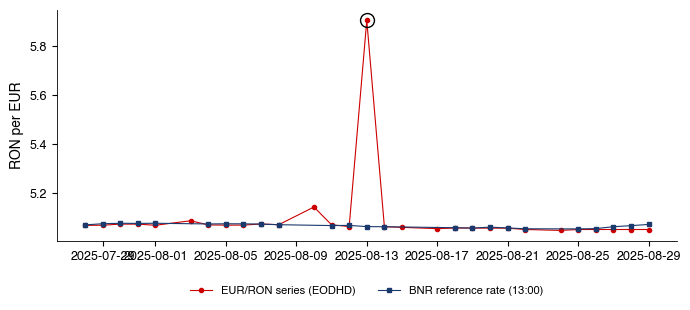

In [8]:
m = load('EUR/RON (market)', start='2015-01-01'); bnr = load('EUR/RON', start='2015-01-01')
vol = lambda x: np.log(x).diff().dropna().std() * np.sqrt(obs_per_year(x))      # each series with its own q
r = np.log(m).diff().dropna()
print(f'1. largest |log change|: {r[r.abs().idxmax()]:+.2%} on {r.abs().idxmax().date()}')
d = pd.Timestamp('2025-08-13'); i = m.index.get_loc(d); prev, nxt = m.index[i - 1], m.index[i + 1]
print(f'2. {prev.date()} {m[prev]:.4f} -> {d.date()} {m[d]:.4f} -> {nxt.date()} {m[nxt]:.4f}; '
      f'log changes {np.log(m[d] / m[prev]):+.2%}, {np.log(m[nxt] / m[d]):+.2%}')
print(f'3. BNR {bnr[d]:.4f}; gap {m[d] - bnr[d]:.4f} RON ({m[d] / bnr[d] - 1:+.1%})')
print(f'4. market series {vol(m):.1%} (q = {obs_per_year(m):.1f}); without 13 Aug 2025 {vol(m.drop(d)):.1%}; '
      f'BNR {vol(bnr):.1%} (q = {obs_per_year(bnr):.1f})')
a, b = '2025-07-28', '2025-08-29'
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(m.loc[a:b].index, m.loc[a:b], 'o-', color=IDAred, lw=0.8, ms=3, label='EUR/RON series (EODHD)')
ax.plot(bnr.loc[a:b].index, bnr.loc[a:b], 's-', color=MainBlue, lw=0.8, ms=3, label='BNR reference rate (13:00)')
ax.plot(d, m[d], 'o', ms=10, mfc='none', mec='black'); ax.set_ylabel('RON per EUR')
legend_outside_bottom(ax, ncol=2, y=-0.15); plt.show()

**Interpretation (solution).** All three signs are present: a 15% move where the BNR rate moves about 0.13% a day, reversed the next day, 0.84 RON away from BNR: a bad tick. One quote adds 1.8 pp to the annualised volatility; the market series is still five times as volatile as the BNR rate, so other bad ticks remain (B1 full audit, Pack 1).

### B2 [Solved]. Three assets on one chart <a id="B2"></a>

**Growth of 1 USD** $G_t = P_t/P_0$ is the value on day $t$ of 1 USD invested on day 0. On a **log scale** equal distances are equal ratios (1 → 2 has the same height as 100 → 200) and a constant growth rate is a straight line. **Drawdown** $DD_t = P_t/M_t - 1$ with the running peak $M_t = \max_{s \le t} P_s$; the maximum drawdown (MDD) is $\min_t DD_t$.

**Questions.**
- How much did 1 USD grow in SPY, gold and Bitcoin since 2015?
- How volatile was each?
- How deep was the worst fall?

**Data.** SPY (adjusted close), gold (close, weekdays), Bitcoin (close, every day), 2 Jan 2015 – 18 Sep 2026, all in USD; each asset on its own calendar.

**Tasks.**
1. Plot the growth of 1 USD, $P_t/P_0$, on a log scale.
2. For each asset compute the multiple, $Y$ and the CAGR.
3. Compute $n$, $q = n/Y$, the daily volatility $\hat\sigma_d$ and the annualised volatility $\hat\sigma_d\sqrt{q}$.
4. Plot the drawdown curves and report each maximum drawdown with its peak and trough dates.

**Report:** the two charts and a table (multiple, CAGR, $q$, volatility, MDD). **Interpretation:** does the asset with the highest CAGR also have the highest volatility and the deepest drawdown?

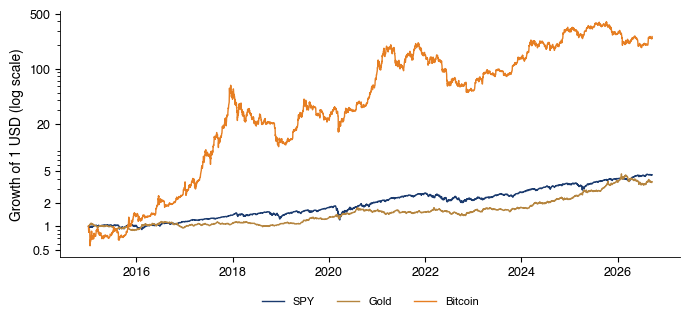

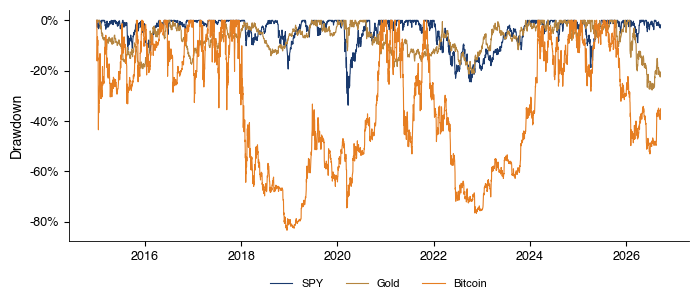

            n      Y  multiple    CAGR         q  daily vol     vol     MDD        peak      trough  DD now
asset                                                                                                      
SPY      2944  11.71    4.5000  0.1371  251.4136     0.0111  0.1756 -0.3372  2020-02-19  2020-03-23 -0.0184
Gold     3050  11.71    3.6832  0.1178  260.4659     0.0101  0.1633 -0.2770  2026-01-28  2026-07-16 -0.2055
Bitcoin  4277  11.71  256.8039  0.6061  365.2500     0.0349  0.6668 -0.8340  2017-12-16  2018-12-15 -0.3515


In [9]:
def core_table(prices):
    """Multiple, CAGR, q, annualised volatility and maximum drawdown of each price series, on its own calendar."""
    rows = []
    for n, p in prices.items():
        Y = (p.index[-1] - p.index[0]).days / 365.25; r = np.log(p).diff().dropna(); q = obs_per_year(p)
        dd = drawdown(p); tr = dd.idxmin(); pk = p.loc[:tr].idxmax()
        rows.append((n, len(r), round(Y, 2), p.iloc[-1] / p.iloc[0], (p.iloc[-1] / p.iloc[0]) ** (1 / Y) - 1, q,
                     r.std(), r.std() * np.sqrt(q), dd.min(), pk.date(), tr.date(), dd.iloc[-1]))
    return pd.DataFrame(rows, columns=['asset', 'n', 'Y', 'multiple', 'CAGR', 'q', 'daily vol', 'vol', 'MDD', 'peak',
                                       'trough', 'DD now']).set_index('asset')


def growth_and_drawdown_charts(prices, cols, ticks):
    fig, ax = plt.subplots(figsize=(8, 3.2))
    for n, p in prices.items():
        ax.plot(p.index, p / p.iloc[0], color=cols[n], lw=1.0, label=n)
    log_axis(ax, ticks); ax.set_ylabel('Growth of 1 USD (log scale)'); legend_outside_bottom(ax, ncol=3, y=-0.12); plt.show()
    fig, ax = plt.subplots(figsize=(8, 3))
    for n, p in prices.items():
        dd = drawdown(p); ax.plot(dd.index, dd, color=cols[n], lw=0.8, label=n)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}')); ax.set_ylabel('Drawdown')
    legend_outside_bottom(ax, ncol=3, y=-0.12); plt.show()


three = {'SPY': load('SPY', start='2015-01-02'), 'Gold': load('Gold', start='2015-01-02'),
         'Bitcoin': load('Bitcoin', start='2015-01-02')}
growth_and_drawdown_charts(three, {'SPY': MainBlue, 'Gold': Amber, 'Bitcoin': Orange}, [0.5, 1, 2, 5, 20, 100, 500])
print(core_table(three).round(4).to_string())

**Interpretation (solution).** Yes in this sample: Bitcoin has the highest CAGR (60.6%), about four times the volatility of SPY and gold (66.7% vs 17.6% and 16.3%) and the deepest drawdown (−83.4%, Dec 2017 – Dec 2018). SPY and gold have similar volatility; gold's worst fall (−27.7%, Jan – Jul 2026) is recent and not yet recovered. One sample of 11.7 years: whether such differences are reliable is the subject of the lecture and of Pack 2.

## Your turn (in class)

### A5 [Proposed]. Returns, CAGR and volatility <a id="A5"></a>

**Model:** A1 and A2–A3 [Solved]. **Inputs:** a stock at $P_0 = 50$, $P_1 = 55$, $P_2 = 44$; a fund that grew from 100 to 250 in 2,922 calendar days; a daily volatility of 1.5%.

**Tasks.**
1. Compute $R_1, R_2, r_1, r_2$, the two sums and the two-day returns $P_2/P_0 - 1$ and $\ln(P_2/P_0)$.
2. Compute $Y$ and the CAGR of the fund.
3. Annualise the daily volatility with $q = 252$ and with $q = 365$.

**Report:** a small table and one sentence on which sum equals the two-day return.

In [10]:
# Your code here

### A6 [Proposed]. A drawdown on paper <a id="A6"></a>

**Model:** A4 [Solved]. **Inputs:** prices on days 0–5: 200, 180, 220, 165, 198, 230.

**Tasks.**
1. Compute the running peak $M_t$ and the drawdown $DD_t$ for every day.
2. Report the maximum drawdown and its day.
3. Recovery after the trough:
   - on which day is the price back at or above the peak before the trough?
   - what gain from the trough did that need?

**Report:** the completed table, the MDD and the recovery day with the gain needed.

In [11]:
# Your code here

## Homework

### B3 [Proposed]. Two more suspicious quotes <a id="B3"></a>

**Model:** B1 [Solved]. **Question:** the market EUR/RON quotes of 22 Apr 2022 and of 6 May 2025 are both more than 0.05 RON from the BNR rate; which one is a bad tick?

**Tasks.**
1. For each date, report the previous quote, the quote and the next quote, and the two daily log changes.
2. Compare each quote with the BNR rate of that day; if BNR published no rate that day (a public holiday), use its last earlier rate.
3. Check the three signs of a bad tick for each date and decide: remove or keep.
4. Plot both episodes, market series against BNR, over about three weeks.

**Report:** one table row per date and the chart. **Interpretation:** why is a gap to BNR alone not enough to remove a quote?

In [12]:
# Your code here

### B4 [Proposed]. Three other assets <a id="B4"></a>

**Model:** B2 [Solved]. **Question:** how did the S&P 500 with equal weights (RSP) and long US Treasuries (TLT) do against SPY since 2015?

**Data.** SPY, RSP and TLT (adjusted close), 2 Jan 2015 – 18 Sep 2026, USD, US trading days.

**Tasks.**
1. Plot the growth of 1 USD of the three ETFs on a log scale.
2. Compute the multiple, the CAGR, $q$ and the annualised volatility of each.
3. Plot the drawdown curves and report each MDD with its peak and trough dates and the drawdown on 18 Sep 2026.

**Report:** the two charts and the table of B2 for the three ETFs. **Interpretation:** are long Treasuries a safe asset in this sample?

In [13]:
# Your code here

### B5 [Proposed]. Drawdowns and recovery time <a id="B5"></a>

**Model:** A4 and B2 [Solved]. **Questions:**
- How deep are the drawdowns of the S&P 500 and of Bitcoin?
- How long are they?

**Data.** S&P 500 (close) from 3 Jan 2000 and Bitcoin (close) from 17 Sep 2014, both to 18 Sep 2026.

**Conventions.** A spell starts on the last day the running peak was set (equal peaks: the latest) and ends on the first close at or above that peak; a spell still open on 18 Sep 2026 is right-censored.

**Tasks.**
1. Compute $DD_t$ for both assets and plot the two underwater curves.
2. Report the maximum drawdown with its peak, trough and recovery dates and prices.
3. Report the longest spell (start, end, calendar and trading days) and the current drawdown.
4. Repeat 2–3 for the S&P 500 from 17 Sep 2014, the Bitcoin horizon.

**Interpretation.** Why must the two MDDs be compared on the same horizon?

In [14]:
# Your code here

### C1 [Proposed]. Critique an AI answer <a id="C1"></a>

**Prompt** sent to an AI assistant: "Using the daily prices of the course data, compute the annualised mean, the annualised volatility and the Sharpe ratio ($r_f = 0$) of SPY and Bitcoin from daily simple returns". **Answer:**

```python
import numpy as np, pandas as pd
URL = 'https://raw.githubusercontent.com/danpele/MFM/main/data/market/'
def load(sym, field='close'):
    return pd.read_csv(URL + sym + '.csv', index_col='date', parse_dates=True)[field].dropna()
spy, btc = load('SPY.US'), load('BTC-USD.CC')
A = 252                                   # trading days per year
for name, p in [('SPY', spy), ('BTC', btc)]:
    r   = p.pct_change().dropna()         # daily simple returns
    mu  = r.mean() * A                    # annualised mean
    vol = r.std() * A                     # annualised volatility
    print(name, mu, vol, mu / vol)        # Sharpe ratio, rf = 0
```

Conclusion of the AI: "Sharpe ratios: SPY 0.03, Bitcoin 0.07. Both assets barely reward their risk."

**Model:** A2–A3 and B2 [Solved]. **Sharpe ratio** (risk-free rate 0): the annualised mean of the daily simple returns divided by their annualised volatility. **Data:** the full history, SPY from 29 Jan 1993 and Bitcoin from 13 Jul 2010, both to 18 Sep 2026.

**Step 1, research design** (write it in the next cell before you run any code):
1. State the hypothesis behind the AI's conclusion as a testable sentence about the two Sharpe ratios.
2. Fix the sample (dates, price field, calendar of each asset) and the comparison you will make.
3. Name one rival explanation for any difference you will find.
4. Say what the result cannot establish, whatever the numbers turn out to be.

**Step 2, the code:**

5. Find the three implementation errors planted in the code.
6. For each, say how you would detect it: a check on the output, a published number, the lecture or the documentation.
7. Write the corrected code and report the annualised mean, volatility and Sharpe ratio of SPY and Bitcoin.
8. Check the corrected result against Step 1:
   - is your rival explanation ruled out?
   - which limitation remains even with the code fixed?
9. Log every error you actually found in `AI_ERRORS.md`: request, answer, error, how found, correction.

**Interpretation:** does the conclusion "both assets barely reward their risk" survive?

**Your research design (Step 1):**

1. Hypothesis: …
2. Sample and comparison: …
3. Rival explanation: …
4. What the result cannot establish: …

In [15]:
def load_file(sym, field='close'):
    """Full daily history (no start date)."""
    return read_market(sym)[field].dropna()

In [16]:
# Your code here

## After the lecture (optional)

These packs use standard errors, the bootstrap and tests that the Chapter 0 lecture introduces. Each pack has its own section below, in the order of the seminar slides; do the exercises in order within a pack.

## Pack 1: Data and calendars <a id="pack1"></a>

B1 full audit, B2 six assets, B6 [all Solved]. Prerequisites: core B1 and B2.

### B1 full audit [Solved]. All bad ticks <a id="B1a"></a>

**Questions.**
- Which quotes of the EUR/RON series from EODHD are errors?
- How much do they distort volatility?

**Data.** The EUR/RON series from EODHD (close), 1 Jan 2015 – 18 Sep 2026, 3,115 rows; the BNR reference rate as the external check.

**Tasks.**
1. Drop weekend rows.
2. Flag weekday quotes more than 0.05 RON from the 11-day centred rolling median.
3. For each flag, compare with the BNR rate of that day (or the last earlier fixing on a holiday); remove only quotes more than 0.05 RON from BNR.
4. Compute the annualised volatility of the raw market series, the cleaned series and the BNR rate, each with its own $q$.

**Report:** an audit table (date, quote, median, BNR, gap, decision), a figure and the three volatilities. **Interpretation:** why does a gap remain between the cleaned series and the BNR rate?

             quote  median     BNR BNR fixing date  gap to BNR decision
2020-07-13  4.7425  4.8368  4.8423      2020-07-13      0.0998  removed
2021-04-19  4.8258  4.9231  4.9261      2021-04-19      0.1003  removed
2021-06-28  4.8265  4.9243  4.9260      2021-06-28      0.0995  removed
2022-01-05  4.3800  4.9435  4.9460      2022-01-05      0.5660  removed
2022-01-07  4.3750  4.9422  4.9436      2022-01-07      0.5686  removed
2022-04-22  4.4000  4.9400  4.9441      2022-04-21      0.5441  removed
2022-08-09  4.5900  4.9019  4.9050      2022-08-09      0.3150  removed
2025-01-07  4.9060  4.9738  4.9749      2025-01-03      0.0689  removed
2025-08-13  5.9065  5.0636  5.0633      2025-08-13      0.8432  removed
2026-05-07  5.2591  5.2005  5.2661      2026-05-07      0.0070     kept
2026-05-08  5.2574  5.2005  5.2364      2026-05-08      0.0210     kept
rows 3115, weekend rows 58, weekday quotes flagged 11, errors removed 9
raw     : q = 266, annualised volatility 12.39%
cleaned : q = 26

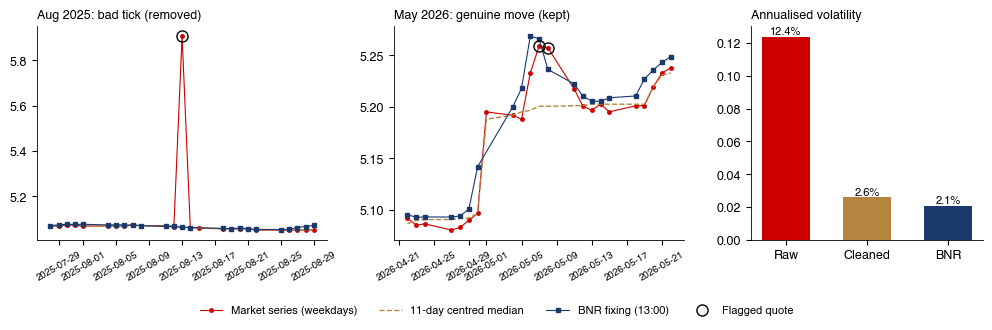

In [17]:
m = load('EUR/RON (market)', start='2015-01-01'); bnr = load('EUR/RON', start='2015-01-01')
vol = lambda x: np.log(x).diff().dropna().std() * np.sqrt(obs_per_year(x))      # FX: observed frequency, not 252
# 1. weekend rows; 2. 0.05 RON from the 11-day centred median of the weekday quotes
wd = m[m.index.dayofweek < 5]; med = wd.rolling(11, center=True, min_periods=3).median()
flagged = wd.index.difference(clean_series(m, max_dev=0.05).index)
# 3. compare each flag with the BNR fixing of that day (last earlier fixing on a holiday); remove only confirmed errors
gap_bnr = pd.Series({d: abs(wd[d] - bnr.asof(d)) for d in flagged})
confirmed = gap_bnr.index[gap_bnr > 0.05]; rule = wd.drop(confirmed)
audit = pd.DataFrame({'quote': wd[flagged], 'median': med[flagged], 'BNR': [bnr.asof(d) for d in flagged],
                      'BNR fixing date': [bnr.index[bnr.index <= d][-1].date() for d in flagged], 'gap to BNR': gap_bnr,
                      'decision': np.where(gap_bnr > 0.05, 'removed', 'kept')})
audit.index = audit.index.date; print(audit.round(4).to_string())
print(f'rows {len(m)}, weekend rows {int((m.index.dayofweek >= 5).sum())}, weekday quotes flagged {len(flagged)}, errors removed {len(confirmed)}')
# 4. three volatilities, each with its own observed q
for lab, x in [('raw', m), ('cleaned', rule), ('BNR', bnr)]:
    print(f'{lab:8s}: q = {obs_per_year(x):.0f}, annualised volatility {vol(x):.2%}')
# the remaining gap: timing and residual quote noise
j = np.log(pd.concat([rule, bnr], axis=1, keys=['mkt', 'bnr']).dropna()).diff().dropna()   # prices joined on common days first
ac = lambda x: np.log(x).diff().dropna().autocorr(1)                                        # each series on its own calendar
print(f"corr of daily changes {j['mkt'].corr(j['bnr']):.2f} on {len(j)} common days; lag-1 autocorrelation market series {ac(rule):.2f}, "
      f"BNR {ac(bnr):.2f}; days of the market series without a BNR fixing {len(rule.index.difference(bnr.index))}")
fig, axes = plt.subplots(1, 3, figsize=(10, 3), gridspec_kw={'width_ratios': [1, 1, 0.8]})
for ax, (a, b, ttl) in zip(axes[:2], [('2025-07-28', '2025-08-29', 'Aug 2025: bad tick (removed)'),
                                       ('2026-04-22', '2026-05-22', 'May 2026: genuine move (kept)')]):
    ax.plot(wd.loc[a:b].index, wd.loc[a:b], 'o-', color=IDAred, lw=0.8, ms=2.5, label='Market series (weekdays)')
    ax.plot(med.loc[a:b].index, med.loc[a:b], color=Amber, lw=1.0, ls='--', label='11-day centred median')
    ax.plot(bnr.loc[a:b].index, bnr.loc[a:b], 's-', color=MainBlue, lw=0.8, ms=2.2, label='BNR fixing (13:00)')
    for d in flagged:
        if pd.Timestamp(a) <= d <= pd.Timestamp(b):
            ax.plot(d, wd[d], 'o', ms=8, mfc='none', mec='black', label='Flagged quote')
    ax.set_title(ttl, loc='left', fontsize=9); ax.tick_params(axis='x', labelsize=7, rotation=30)
v = [vol(m), vol(rule), vol(bnr)]
axes[2].bar(['Raw', 'Cleaned', 'BNR'], v, color=[IDAred, Amber, MainBlue], width=0.6)
for k, x in enumerate(v):
    axes[2].annotate(f'{x:.1%}', (k, x), xytext=(0, 2), textcoords='offset points', ha='center', fontsize=8)
axes[2].set_title('Annualised volatility', loc='left', fontsize=9)
bottom_legend(fig, ncol=4); plt.show()

**Interpretation (solution).** Nine bad ticks multiply volatility by almost five. The gap that remains is consistent with timing differences (the market quote is not taken at the 13:00 fixing) and residual quote noise; daily data cannot separate the two. Use the official BNR rate: a threshold rule removes gross errors, not the remaining differences. The centred median uses future quotes, so this is retrospective cleaning, not a real-time filter.

### B2 six assets [Solved]. A cross-asset dashboard <a id="B2f"></a>

**Questions.**
- How much did 1 USD grow in six asset classes since 2015?
- How volatile was each?

**Data.** SPY (adjusted close), Euro Stoxx 50 and Nikkei 225 (close, converted to USD), gold (weekday quotes), TLT (adjusted close), Bitcoin (close), 2 Jan 2015 – 18 Sep 2026.

**Tasks.**
1. Convert Euro Stoxx 50 and Nikkei 225 to USD: $P^{USD} = P^{EUR} \times$ (USD per EUR), $P^{USD} = P^{JPY}/$(JPY per USD), with the FRED rate of the same day or, if missing, the last rate at most 5 calendar days earlier.
2. Plot the growth of 1 USD, $P_t/P_0$, on a log scale.
3. For each asset compute $n$, $Y$, $q = n/Y$, the multiple, the CAGR and the volatility $\hat\sigma_d\sqrt{q}$.
4. Recompute each volatility with $q = 252$.

**Report:** the chart and a table ($q$, multiple, CAGR, volatility, volatility with 252). **Interpretation:**
- For which assets does the choice of $q$ matter?
- Why does it matter for them?

Check gold against the GLD ETF.

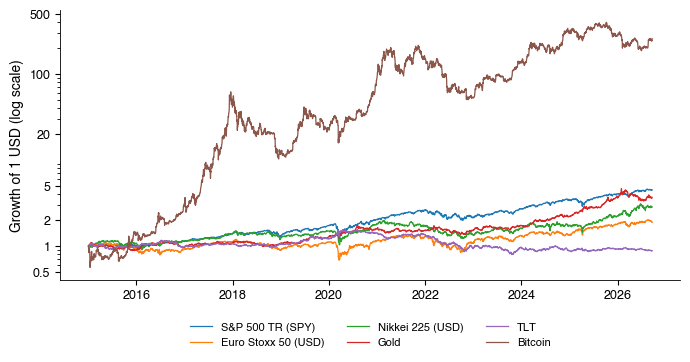

                        n       Y        q  multiple   CAGR    vol  vol with 252
asset                                                                           
S&P 500 TR (SPY)     2944  11.710  251.414     4.500  0.137  0.176         0.176
Euro Stoxx 50 (USD)  3003  11.710  256.452     1.895  0.056  0.207         0.205
Nikkei 225 (USD)     2862  11.702  244.582     2.848  0.094  0.213         0.216
Gold                 3050  11.710  260.466     3.683  0.118  0.163         0.161
TLT                  2944  11.710  251.414     0.884 -0.010  0.147         0.148
Bitcoin              4277  11.710  365.250   256.804  0.606  0.667         0.554


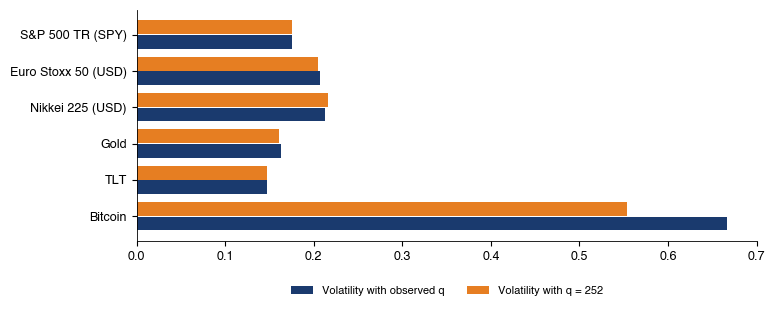

GLD cross-check: vol 0.163 (252 trading days); gold: 0.1633 vs 0.1606


In [18]:
px = load_panel(['SPY', 'Euro Stoxx 50', 'Nikkei 225', 'Gold', 'US Treasuries 20y+ (TLT)', 'Bitcoin'])
fx_usd = load_panel(['USD per EUR', 'JPY per USD'])
assets = {'S&P 500 TR (SPY)': px['SPY'].dropna(),
          'Euro Stoxx 50 (USD)': to_usd(px['Euro Stoxx 50'].dropna(), fx_usd['USD per EUR']),
          'Nikkei 225 (USD)': to_usd(px['Nikkei 225'].dropna(), fx_usd['JPY per USD'], invert=True),
          'Gold': px['Gold'].dropna(), 'TLT': px['US Treasuries 20y+ (TLT)'].dropna(), 'Bitcoin': px['Bitcoin'].dropna()}
assets = {k: v.loc['2015-01-02':] for k, v in assets.items()}
fig, ax = plt.subplots(figsize=(8, 3.5)); rows = []
for n, p in assets.items():
    ax.plot(p.index, p / p.iloc[0], lw=0.9, label=n)
    q = obs_per_year(p); Y = (p.index[-1] - p.index[0]).days / 365.25; r = np.log(p).diff().dropna()
    rows.append((n, len(r), Y, q, p.iloc[-1] / p.iloc[0], (p.iloc[-1] / p.iloc[0]) ** (1 / Y) - 1, r.std() * np.sqrt(q), r.std() * np.sqrt(252)))
log_axis(ax, [0.5, 1, 2, 5, 20, 100, 500]); ax.set_ylabel('Growth of 1 USD (log scale)')
legend_outside_bottom(ax, ncol=3, y=-0.12); plt.show()
tab = pd.DataFrame(rows, columns=['asset', 'n', 'Y', 'q', 'multiple', 'CAGR', 'vol', 'vol with 252']).set_index('asset')
print(tab.round(3).to_string())
fig, ax = plt.subplots(figsize=(8, 3)); yy = np.arange(len(tab))
ax.barh(yy + 0.2, tab['vol'], 0.38, color=MainBlue, label='Volatility with observed q')
ax.barh(yy - 0.2, tab['vol with 252'], 0.38, color=Orange, label='Volatility with q = 252')
ax.set_yticks(yy); ax.set_yticklabels(tab.index); ax.invert_yaxis(); legend_outside_bottom(ax, ncol=2, y=-0.15); plt.show()
gld = fetch_daily('GLD.US', 'market', 'adjusted_close', start='2015-01-02')
print(f"GLD cross-check: vol {np.log(gld).diff().dropna().std() * np.sqrt(252):.3f} (252 trading days); gold: {tab.loc['Gold', 'vol']:.4f} vs {tab.loc['Gold', 'vol with 252']:.4f}")

**Interpretation (solution).** $q$ matters for Bitcoin (66.7% vs 55.4%, 11 pp), not for gold (16.3% vs 16.1%, 0.3 pp). Euro Stoxx 50 and Nikkei 225 exclude dividends: their gap to SPY overstates the difference in total return.

### B6 [Solved]. Correlations and calendars <a id="B6"></a>

**Questions.**
- How much do the calendar and the estimator change a correlation?
- Did the stock–bond correlation change?

**Data.** S&P 500 and Bitcoin (close) and TLT (adjusted close), daily log returns; Bitcoin – S&P 500 in 1 Jan 2022 – 18 Sep 2026; S&P 500 – TLT in 2010–2020 and 2022–2026.

**Tasks.**
1. Bitcoin – S&P 500 whole-period correlation on common days (prices joined first).
2. The same with the S&P 500 forward-filled on weekends, and with weekly returns: last common-day price of each week ending on Friday (Thursday if Friday is a holiday); an incomplete final week is dropped.
3. The mean of the 252-day rolling correlation over 2022–2026 (windows may start in 2021).
4. S&P 500 – TLT in both periods, with both estimators.
5. Stock–bond change: $\hat\rho_1$ (2010–2020, $n_1$ days), $\hat\rho_2$ (2022–2026, $n_2$ days), $z_i = \operatorname{atanh}\hat\rho_i$, $SE_z = \sqrt{1/(n_1-3) + 1/(n_2-3)}$ and $z = (z_2 - z_1)/SE_z$ (Fisher, 1915; iid pairs from a bivariate Normal distribution).
6. The iid 95% interval of the population difference $\rho_2 - \rho_1$: $(\hat\rho_2 - \hat\rho_1) \pm 1.96\sqrt{(1-\hat\rho_1^2)^2/(n_1-3) + (1-\hat\rho_2^2)^2/(n_2-3)}$.

**Report:** a plot of the rolling correlations, a table method / sample size / correlation, $z$, its $p$-value and the interval of the change. **Interpretation:**
- Which estimator answers "what was the correlation in 2022–2026"?
- What does the interval of the change allow you to say?
- What can it not establish?

                                 n  correlation
Bitcoin - S&P 500, 2022-2026                   
common days                   1182        0.419
forward-filled                1722        0.392
weekly (Friday)                246        0.299
mean rolling 252              1182        0.378
S&P 500 - TLT 2010-2020: whole period -0.474, mean rolling 252 -0.427, n = 2769
S&P 500 - TLT 2022-2026: whole period 0.109, mean rolling 252 0.082, n = 1182


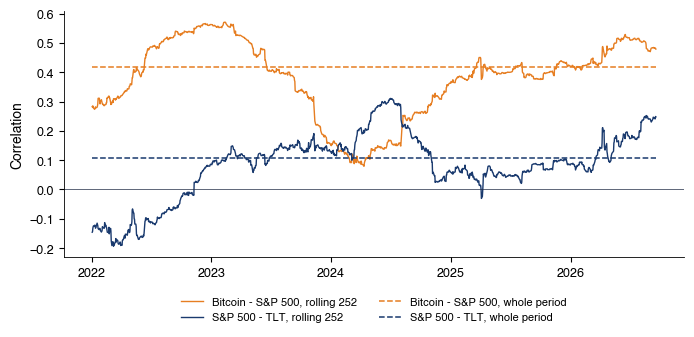

5. rho_1 = -0.4740 (n1 = 2769), rho_2 = 0.1087 (n2 = 1182); z1 = -0.5152, z2 = 0.1091; SE_z = 0.0348; z = 17.9, p = 4.9e-72
6. change +0.583, SE 0.0323, iid 95% interval [0.519, 0.646]


In [19]:
from scipy import stats
eq, btc, tlt = load('S&P 500'), load('Bitcoin'), load('US Treasuries 20y+ (TLT)')
cb = np.log(pd.concat([eq, btc], axis=1).dropna()).diff().dropna()                          # 1. prices joined first
ffill = np.log(pd.concat([eq.reindex(btc.index).ffill(), btc], axis=1).loc['2021-12-31':]).diff().dropna().loc['2022':]
wp = pd.concat([eq, btc], axis=1).dropna().resample('W-FRI').last()                          # 2. weekly, Friday to Friday
weekly = np.log(wp[wp.index <= cb.index[-1]]).diff().dropna().loc['2022':]
roll_cb = cb.iloc[:, 0].rolling(252).corr(cb.iloc[:, 1])                                     # 3. rolling 252
sb = np.log(pd.concat([eq, tlt], axis=1).dropna()).diff().dropna(); roll_sb = sb.iloc[:, 0].rolling(252).corr(sb.iloc[:, 1])
tab = pd.DataFrame([('common days', len(cb.loc['2022':]), cb.loc['2022':].corr().iloc[0, 1]),
                    ('forward-filled', len(ffill), ffill.corr().iloc[0, 1]),
                    ('weekly (Friday)', len(weekly), weekly.corr().iloc[0, 1]),
                    ('mean rolling 252', len(cb.loc['2022':]), roll_cb.loc['2022':].mean())],
                   columns=['Bitcoin - S&P 500, 2022-2026', 'n', 'correlation']).set_index('Bitcoin - S&P 500, 2022-2026')
print(tab.round(3).to_string())
for a, b in [('2010', '2020'), ('2022', '2026')]:                                             # 4.
    print(f'S&P 500 - TLT {a}-{b}: whole period {sb.loc[a:b].corr().iloc[0, 1]:.3f}, mean rolling 252 {roll_sb.loc[a:b].mean():.3f}, n = {len(sb.loc[a:b])}')
fig, ax = plt.subplots(figsize=(8, 3.2))
rc, rs = roll_cb.loc['2022':], roll_sb.loc['2022':]
ax.plot(rc.index, rc, color=Orange, lw=1.0, label='Bitcoin - S&P 500, rolling 252')
ax.plot(rs.index, rs, color=MainBlue, lw=1.0, label='S&P 500 - TLT, rolling 252')
ax.hlines(tab.iloc[0, 1], rc.index[0], rc.index[-1], color=Orange, ls='--', label='Bitcoin - S&P 500, whole period')
ax.hlines(sb.loc['2022':].corr().iloc[0, 1], rs.index[0], rs.index[-1], color=MainBlue, ls='--', label='S&P 500 - TLT, whole period')
ax.axhline(0, color=Gray, lw=0.5); ax.set_ylabel('Correlation'); legend_outside_bottom(ax, ncol=2, y=-0.12); plt.show()
# 5.-6. the stock-bond change
a_, c_ = sb.loc['2010':'2020'].values, sb.loc['2022':].values; n1, n2 = len(a_), len(c_)
r1, r2 = np.corrcoef(a_.T)[0, 1], np.corrcoef(c_.T)[0, 1]
se_z = np.sqrt(1 / (n1 - 3) + 1 / (n2 - 3)); z = (np.arctanh(r2) - np.arctanh(r1)) / se_z
se_iid = np.sqrt((1 - r1 ** 2) ** 2 / (n1 - 3) + (1 - r2 ** 2) ** 2 / (n2 - 3))
print(f'5. rho_1 = {r1:.4f} (n1 = {n1}), rho_2 = {r2:.4f} (n2 = {n2}); z1 = {np.arctanh(r1):.4f}, z2 = {np.arctanh(r2):.4f}; '
      f'SE_z = {se_z:.4f}; z = {z:.1f}, p = {2 * stats.norm.sf(abs(z)):.1e}')
print(f'6. change {r2 - r1:+.3f}, SE {se_iid:.4f}, iid 95% interval [{r2 - r1 - 1.96 * se_iid:.3f}, {r2 - r1 + 1.96 * se_iid:.3f}]')

**Interpretation (solution).** The whole-period correlation answers the question; the mean of rolling correlations averages one-year windows (some starting in 2021), a different estimand; the calendar alone moves the Bitcoin estimate between 0.30 and 0.42. The stock–bond change (+0.58, interval [0.52, 0.65]) is far larger than iid sampling error, but the interval cannot establish its cause, and its iid assumption ignores volatility clustering (B6 extended).

## Pack 2: Precision <a id="pack2"></a>

A7, B2 extended [Solved]. Prerequisites: Pack 1, the Chapter 0 lecture.

### A7 [Solved]. How precise is a mean return? <a id="A7"></a>

**Question.** SPY returned on average about 14% a year in 2015–2026; how precisely does this sample pin down the expected annual return?

**Data.** SPY (adjusted close), daily simple returns $R_t$, 2 Jan 2015 – 18 Sep 2026; $q$ and $Y$ as in B2 six assets.

**Tasks.**
1. Compute the annualised mean $\hat\mu_a = q\bar R$ and the annualised volatility $\hat\sigma_a = s_R\sqrt{q}$.
2. With iid returns, $SE(\hat\mu_a) = q s_R/\sqrt{n} = \hat\sigma_a/\sqrt{Y}$ (since $n = qY$): compute it and the 95% interval $\hat\mu_a \pm 1.96\,SE$.
3. How many years of data would give a 95% interval of ±2 pp with the same volatility?

**Report:** $\hat\mu_a$, $\hat\sigma_a$, the SE, the interval and the number of years. **Interpretation:** why does sampling daily instead of monthly not make the mean more precise?

In [20]:
spy = load('SPY', start='2015-01-02'); R = spy.pct_change().dropna()
q = obs_per_year(spy); Y = (spy.index[-1] - spy.index[0]).days / 365.25
mu_a, sig_a = q * R.mean(), R.std(ddof=1) * np.sqrt(q); se = sig_a / np.sqrt(Y)
print(f'1. n = {len(R)}, q = {q:.1f}, Y = {Y:.2f}; mean R = {R.mean():.4%}, s_R = {R.std(ddof=1):.3%}: mu_a = {mu_a:.1%}, sigma_a = {sig_a:.1%}')
print(f'2. SE = {sig_a:.3f} / sqrt({Y:.2f}) = {se:.4f}; 95% interval [{mu_a - 1.96 * se:.1%}, {mu_a + 1.96 * se:.1%}]')
print(f'3. years for +/- 2 pp: (1.96 x {sig_a:.3f} / 0.02)^2 = {(1.96 * sig_a / 0.02) ** 2:.0f}')

1. n = 2944, q = 251.4, Y = 11.71; mean R = 0.0572%, s_R = 1.105%: mu_a = 14.4%, sigma_a = 17.5%
2. SE = 0.175 / sqrt(11.71) = 0.0512; 95% interval [4.3%, 24.4%]
3. years for +/- 2 pp: (1.96 x 0.175 / 0.02)^2 = 295


**Interpretation (solution).** The SE depends on the span $Y$, not on the number of observations: more frequent sampling adds observations but not information about the mean. The same logic sets the precision of the Sharpe ratio (B2 extended).

### B2 extended [Solved]. How precise is a Sharpe ratio? <a id="B2x"></a>

**Question.** Is SPY's Sharpe ratio precise enough to rank it above gold?

**Data.** The six series of B2 six assets, daily simple returns $R_t$, risk-free rate 0.

**Tasks.**
1. Compute $SR_a = \sqrt{q}\,\bar R/s_R$ for SPY and the daily $SR_d = \bar R/s_R$.
2. Compute the asymptotic iid standard error for returns following the Normal distribution (Lo, 2002): $SE = \sqrt{q(1 + SR_d^2/2)/T}$, and the 95% interval $SR_a \pm 1.96\,SE$.
3. Stationary bootstrap (Politis and Romano, 1994; mean block 20, 2,000 resamples, `default_rng(42)`): 95% percentile interval of SPY's SR; repeat for the other five assets.
4. On the common days of SPY and gold, bootstrap the paired difference of their Sharpe ratios (both with $q = 252$) and report its 95% interval.

**Report:** the SPY calculation, a chart of the intervals, the difference with its interval. **Interpretation:** does the table of B2 six assets rank SPY above gold?

                        T        q   SR_a   SR_d  SE Lo  SE Opdyke  SR boot lo  SR boot hi  CAGR boot lo  CAGR boot hi
asset                                                                                                                 
S&P 500 TR (SPY)     2944  251.414  0.821  0.052  0.292      0.296       0.327       1.401         0.044         0.234
Euro Stoxx 50 (USD)  3003  256.452  0.368  0.023  0.292      0.294      -0.168       0.922        -0.056         0.177
Nikkei 225 (USD)     2862  244.582  0.527  0.034  0.292      0.292       0.077       0.989        -0.007         0.200
Gold                 3050  260.466  0.765  0.047  0.292      0.295       0.243       1.335         0.026         0.224
TLT                  2944  251.414  0.002  0.000  0.292      0.292      -0.528       0.512        -0.085         0.066
Bitcoin              4277  365.250  1.050  0.055  0.292      0.294       0.439       1.660         0.067         1.399
SPY step by step: SR_d = 0.82/sqrt(251.4) = 0.05

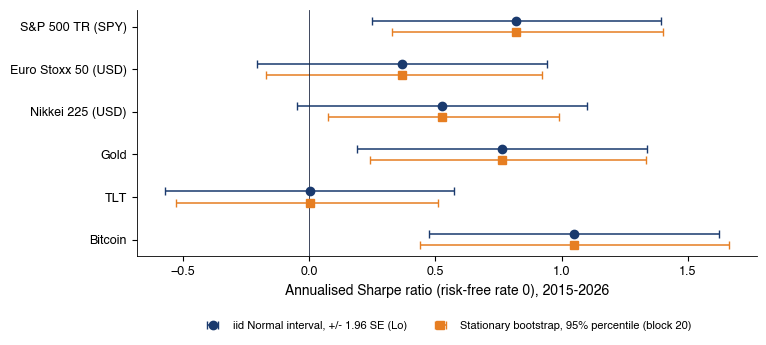

SPY - gold (2944 common days): +0.06, 95% percentile interval [-0.65, +0.88]; share of positive differences 60%; p = 0.81


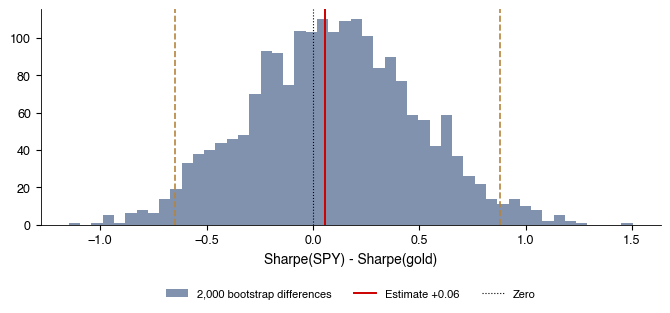

In [21]:
rng = np.random.default_rng(42)
rows, draws = [], {}
for n, p in assets.items():
    q = obs_per_year(p); years = (p.index[-1] - p.index[0]).days / 365.25
    r = np.log(p).diff().dropna().values; R = np.expm1(r); sr = sharpe(R, q)
    cs, ss = [], []
    for _ in range(2000):
        i = sb_index(len(r), 20, rng); cs.append(np.exp(r[i].sum() / years) - 1); ss.append(sharpe(R[i], q))
    lo, hi = np.percentile(ss, [2.5, 97.5]); draws[n] = (lo, hi)
    rows.append((n, len(R), q, sr, R.mean() / R.std(ddof=1), se_lo(R, q), se_opdyke(R, q), lo, hi, *np.percentile(cs, [2.5, 97.5])))
tab = pd.DataFrame(rows, columns=['asset', 'T', 'q', 'SR_a', 'SR_d', 'SE Lo', 'SE Opdyke', 'SR boot lo', 'SR boot hi',
                                  'CAGR boot lo', 'CAGR boot hi']).set_index('asset')
print(tab.round(3).to_string())
s = tab.loc['S&P 500 TR (SPY)']
print(f"SPY step by step: SR_d = {s['SR_a']:.2f}/sqrt({s['q']:.1f}) = {s['SR_d']:.3f}; SE = sqrt({s['q']:.1f} x (1 + {s['SR_d']:.3f}^2/2)/{int(s['T'])}) = {s['SE Lo']:.3f}; "
      f"iid 95% [{s['SR_a'] - 1.96 * s['SE Lo']:.2f}, {s['SR_a'] + 1.96 * s['SE Lo']:.2f}]; bootstrap [{s['SR boot lo']:.2f}, {s['SR boot hi']:.2f}]")
fig, ax = plt.subplots(figsize=(8, 3.2)); yy = np.arange(len(tab))
ax.errorbar(tab['SR_a'], yy - 0.13, xerr=1.96 * tab['SE Lo'], fmt='o', color=MainBlue, capsize=3, label='iid Normal interval, +/- 1.96 SE (Lo)')
ax.errorbar(tab['SR_a'], yy + 0.13, xerr=[tab['SR_a'] - tab['SR boot lo'], tab['SR boot hi'] - tab['SR_a']], fmt='s', color=Orange,
            capsize=3, label='Stationary bootstrap, 95% percentile (block 20)')
ax.axvline(0, color=Gray, lw=0.6); ax.set_yticks(yy); ax.set_yticklabels(tab.index); ax.invert_yaxis()
ax.set_xlabel('Annualised Sharpe ratio (risk-free rate 0), 2015-2026'); legend_outside_bottom(ax, ncol=2, y=-0.22); plt.show()
# 4. SPY minus gold on common days, paired bootstrap (both with q = 252)
j = np.log(pd.concat([assets['S&P 500 TR (SPY)'], assets['Gold']], axis=1).dropna()).diff().dropna(); Rj = np.expm1(j.values)
d0 = sharpe(Rj[:, 0], 252) - sharpe(Rj[:, 1], 252)
ds = np.array([sharpe(Rj[i, 0], 252) - sharpe(Rj[i, 1], 252) for i in (sb_index(len(Rj), 20, rng) for _ in range(2000))])
lo, hi = np.percentile(ds, [2.5, 97.5])
print(f'SPY - gold ({len(Rj)} common days): {d0:+.2f}, 95% percentile interval [{lo:+.2f}, {hi:+.2f}]; '
      f'share of positive differences {(ds > 0).mean():.0%}; p = {min(1, 2 * min((ds <= 0).mean(), (ds >= 0).mean())):.2f}')
fig, ax = plt.subplots(figsize=(8, 2.8))
ax.hist(ds, bins=50, color=MainBlue, alpha=0.55, label='2,000 bootstrap differences')
ax.axvline(d0, color=IDAred, lw=1.4, label=f'Estimate {d0:+.2f}')
for v in (lo, hi):
    ax.axvline(v, color=Amber, ls='--', lw=1.2)
ax.axvline(0, color='black', ls=':', lw=0.8, label='Zero'); ax.set_xlabel('Sharpe(SPY) - Sharpe(gold)')
legend_outside_bottom(ax, ncol=3, y=-0.25); plt.show()

**Interpretation (solution).** Every iid SE is about $1/\sqrt{11.71} = 0.29$: with daily data the SE hardly depends on the asset. The SPY–gold difference (+0.06) has an interval that contains 0: 11.7 years do not rank SPY above gold; the B2 table describes the sample.

**Optional check: sensitivity to the mean block length** (blocks of 5 and 60 days, 1,000 resamples each, own generator `default_rng(42)`).

In [22]:
rng_b = np.random.default_rng(42); sens = []
for n, p in assets.items():
    q = obs_per_year(p); r = np.log(p).diff().dropna().values; R = np.expm1(r); row = [n]
    for mb in (5, 60):
        ss = [sharpe(R[i], q) for i in (sb_index(len(r), mb, rng_b) for _ in range(1000))]
        row.append(f'[{np.percentile(ss, 2.5):.2f}, {np.percentile(ss, 97.5):.2f}]')
    sens.append(row)
print(pd.DataFrame(sens, columns=['asset', 'SR 95% block 5', 'SR 95% block 60']).set_index('asset').to_string())

                    SR 95% block 5 SR 95% block 60
asset                                             
S&P 500 TR (SPY)      [0.29, 1.39]    [0.39, 1.34]
Euro Stoxx 50 (USD)  [-0.21, 0.98]   [-0.14, 0.91]
Nikkei 225 (USD)      [0.04, 1.04]    [0.11, 0.98]
Gold                  [0.19, 1.36]    [0.22, 1.31]
TLT                  [-0.52, 0.53]   [-0.52, 0.54]
Bitcoin               [0.51, 1.66]    [0.44, 1.72]


**Optional extension: all pairs of the five non-crypto assets** (joint bootstrap of each Sharpe difference on common days, generator `default_rng(2026)`; Bonferroni: 10 tests, each at 0.5%).

In [23]:
import itertools
rng_pairs = np.random.default_rng(2026)
for a, b in itertools.combinations([k for k in assets if k != 'Bitcoin'], 2):
    jj = np.log(pd.concat([assets[a], assets[b]], axis=1).dropna()).diff().dropna(); Rp = np.expm1(jj.values)
    dd = np.array([sharpe(Rp[i, 0], 252) - sharpe(Rp[i, 1], 252) for i in (sb_index(len(Rp), 20, rng_pairs) for _ in range(2000))])
    p = min(1, 2 * min((dd <= 0).mean(), (dd >= 0).mean()))
    print(f'{a} - {b}: {sharpe(Rp[:, 0], 252) - sharpe(Rp[:, 1], 252):+.2f}, 95% CI [{np.percentile(dd, 2.5):+.2f}, {np.percentile(dd, 97.5):+.2f}], '
          f'99.5% CI [{np.percentile(dd, 0.25):+.2f}, {np.percentile(dd, 99.75):+.2f}], bootstrap p = {p:.3f}')

S&P 500 TR (SPY) - Euro Stoxx 50 (USD): +0.46, 95% CI [+0.09, +0.85], 99.5% CI [-0.06, +1.03], bootstrap p = 0.012


S&P 500 TR (SPY) - Nikkei 225 (USD): +0.32, 95% CI [-0.04, +0.75], 99.5% CI [-0.18, +0.95], bootstrap p = 0.097


S&P 500 TR (SPY) - Gold: +0.06, 95% CI [-0.63, +0.82], 99.5% CI [-0.91, +1.11], bootstrap p = 0.824


S&P 500 TR (SPY) - TLT: +0.82, 95% CI [+0.05, +1.62], 99.5% CI [-0.32, +1.97], bootstrap p = 0.036


Euro Stoxx 50 (USD) - Nikkei 225 (USD): -0.14, 95% CI [-0.52, +0.23], 99.5% CI [-0.67, +0.44], bootstrap p = 0.467


Euro Stoxx 50 (USD) - Gold: -0.39, 95% CI [-1.04, +0.30], 99.5% CI [-1.25, +0.55], bootstrap p = 0.257


Euro Stoxx 50 (USD) - TLT: +0.37, 95% CI [-0.38, +1.13], 99.5% CI [-0.72, +1.42], bootstrap p = 0.321


Nikkei 225 (USD) - Gold: -0.24, 95% CI [-0.91, +0.51], 99.5% CI [-1.20, +0.77], bootstrap p = 0.505


Nikkei 225 (USD) - TLT: +0.55, 95% CI [-0.12, +1.24], 99.5% CI [-0.42, +1.60], bootstrap p = 0.109


Gold - TLT: +0.76, 95% CI [+0.17, +1.34], 99.5% CI [-0.09, +1.63], bootstrap p = 0.008


## Pack 3: Return arithmetic <a id="pack3"></a>

A8 [Solved], A9, A10. Prerequisites: Pack 2.

### A8 [Solved]. Volatility drag <a id="A8"></a>

**Question.** Can a positive average return go together with falling wealth? **Notation** (daily): $m = E[r]$, $a = E[R]$, $v_R = \operatorname{Var}(R)$, $v_r = \operatorname{Var}(r)$, $r = \ln(1 + R)$.

**Data.** Bitcoin, daily close in USD, 17 Sep 2014 (457.33) to 18 Sep 2026 (80,901.46), 4,384 daily returns, 365 a year.

**Tasks.**
1. Expand $\ln(1+R)$ to second order and show $m \approx a - (v_R + a^2)/2 \approx a - v_r/2$ for small daily returns.
2. For Bitcoin, fill a daily-to-annual table: log mean ×365, drag $v_r \times 365/2$, implied simple mean, CAGR $= e^{365m} - 1$; compare with the CAGR from the two endpoint prices.
3. An asset has an annual arithmetic mean of 10% and a volatility of 60%: approximate its expected log growth and CAGR.

**Interpretation.** Why can the typical path lose money when the mean return is positive?

In [24]:
btc = load('Bitcoin', start='2014-09-17')
r = np.log(btc).diff().dropna(); R = np.expm1(r)
m_d, s_d = r.mean(), r.std()
mu_log = m_d * 365; half_var = s_d ** 2 * 365 / 2
years = (btc.index[-1] - btc.index[0]).days / 365.25
print(f'2. daily log mean {m_d:.4%}, daily sd {s_d:.3%}; log mean x 365 {mu_log:.1%}, drag {half_var:.3f}')
print(f'   implied simple mean {mu_log + half_var:.1%} (direct: 365 x mean of R_t = {R.mean() * 365:.1%}); CAGR = e^(365 m) - 1 = {np.exp(mu_log) - 1:.1%} '
      f'(from {btc.iloc[0]:.2f} to {btc.iloc[-1]:.2f}: {(btc.iloc[-1] / btc.iloc[0]) ** (1 / years) - 1:.1%})')
print(f'3. log growth 0.10 - 0.60^2/2 = {0.10 - 0.6 ** 2 / 2:.3f}, CAGR {np.exp(0.10 - 0.18) - 1:.1%}; '
      f'exact if annual log returns are Normal: ln 1.10 - 0.18 = {np.log(1.1) - 0.18:.3f}, CAGR {np.exp(np.log(1.1) - 0.18) - 1:.1%}')

2. daily log mean 0.1181%, daily sd 3.485%; log mean x 365 43.1%, drag 0.222
   implied simple mean 65.3% (direct: 365 x mean of R_t = 65.2%); CAGR = e^(365 m) - 1 = 53.9% (from 457.33 to 80901.46: 53.9%)
3. log growth 0.10 - 0.60^2/2 = -0.080, CAGR -7.7%; exact if annual log returns are Normal: ln 1.10 - 0.18 = -0.085, CAGR -8.1%


### A9 [Proposed]. When the $\sqrt{q}$ rule fails <a id="A9"></a>

**Model:** A2–A3 and A8 [Solved]. **Theory** (daily log returns, stationary, variance $\sigma^2$, autocorrelations $\rho_j$):
1. For $k = 3$, write $\operatorname{Var}(r_1 + r_2 + r_3)$ as the sum of the nine covariances; then generalise to $\operatorname{Var}(\sum_{t=1}^{k} r_t) = k\sigma^2[1 + 2\sum_{j=1}^{k-1}(1 - j/k)\rho_j]$.
2. For a *hypothetical* AR(1), $\rho_j = \rho^j$, find the limit of the bracket as $k \to \infty$.

**Data:** BNR EUR/RON, 4 Jul 2005 – 18 Sep 2026, 5,352 daily log changes.

3. Compute $\hat\rho_1$, the $\sqrt{252}$ volatility and its hypothetical AR(1) correction.
4. Compute the autocorrelations at lags 1–10 and the volatility from month-end changes ×$\sqrt{12}$.
5. The EUR/RON series from EODHD (B1) has $\hat\rho_1 = -0.57$:
   - what would the AR(1) factor be?
   - why is it the wrong fix?

**Interpretation.**
- Does positive autocorrelation hide risk or invent it?
- Is $\hat\rho_1$ enough?

In [25]:
# Your code here

### A10 [Proposed]. The standard error of a Sharpe ratio <a id="A10"></a>

**Model:** A8, A7 and B2 extended [Solved]. **Setting:** $T$ iid daily returns with mean $\mu$, variance $\sigma^2$, central moments $\mu_3, \mu_4$ (finite), skewness $\gamma_3 = \mu_3/\sigma^3$, ordinary (not excess) kurtosis $\gamma_4 = \mu_4/\sigma^4$; daily $SR = \mu/\sigma$. **Data:** SPY (B2 extended): $SR_a = 0.82$, $q = 251.4$, $T = 2944$, $Y = 11.71$, $\gamma_3 = -0.31$, $\gamma_4 = 17.1$.

1. Gradient: for $g(\mu, \sigma^2) = \mu/\sigma$, compute $\nabla g$.
2. Quadratic form: $\sqrt{T}(\hat\mu - \mu, \hat\sigma^2 - \sigma^2) \to N(0, \Sigma)$, $\Sigma = [[\sigma^2, \mu_3], [\mu_3, \mu_4 - \sigma^4]]$; compute $\nabla g^\top \Sigma \nabla g$ and its Normal case (Lo, 2002).
3. Annual scaling, Normal case: with $SR_a = \sqrt{q}\,SR_d$ and $T = qY$, show that the asymptotic variance is $\operatorname{Var}(\widehat{SR}_a) \approx (1 + SR_a^2/(2q))/Y$ (an approximation for large $T$, not an exact finite-sample result).
4. Compute SPY's asymptotic SE three ways: Normal daily, general daily (with $\gamma_3$, $\gamma_4$), and the same Normal formula with $q = 1$, $\sqrt{(1 + SR_a^2/2)/Y}$, as if the span were observed as annual returns; state the sampling assumption of each.

**Interpretation.** Why does sampling more often than monthly barely help?

In [26]:
# Your code here

## Pack 4: Correlation inference <a id="pack4"></a>

B6 extended, A11, A12, C2. Prerequisites: Packs 1–2.

### B6 extended [Proposed]. Does the stock–bond change survive dependence? <a id="B6x"></a>

**Model:** B6 (iid interval of a correlation change) and B2 extended (stationary bootstrap) [Solved]. **Data:** B6, S&P 500 – TLT daily log returns on common days: 2010–2020 ($n_1 = 2769$) and 2022 – 18 Sep 2026 ($n_2 = 1182$).

1. Stationary bootstrap each period separately (block 20, 2,000 resamples, `default_rng(42)`): recompute $\hat\rho_2^* - \hat\rho_1^*$ on each pair of resamples.
2. Report the 95% percentile interval of $\rho_2 - \rho_1$ and plot the histogram of the bootstrap changes with both intervals.
3. Compare its width with the width of the iid interval of B6 (task 6).
4. For A11 (e): Bitcoin – S&P 500 (2022–2026), Fisher and bootstrap intervals for the daily and the weekly correlation, and a joint bootstrap of their difference (weeks resampled in blocks of mean 4, generator `default_rng(2026)`, both correlations recomputed from each resample).

**Interpretation.**
- Why is the bootstrap interval wider?
- Does the conclusion of B6 survive?

In [27]:
# Your code here

### A11 [Proposed]. Why is the weekly correlation lower? <a id="A11"></a>

**Model:** B6 [Solved]. **Data:** $x_t$ = S&P 500, $y_t$ = Bitcoin, daily log returns on common days, 2022 – 18 Sep 2026, $n = 1182$; $\gamma(j) = \operatorname{Cov}(x_t, y_{t-j})$.

1. For sums of 5 consecutive common-day returns $X, Y$, draw the $5 \times 5$ grid of covariances and show $\operatorname{Cov}(X,Y) = 5\gamma(0) + \sum_{j=1}^{4}(5-j)[\gamma(j) + \gamma(-j)]$ and $\operatorname{Var}(X) = 5\sigma_x^2 f_x$, $f_x = 1 + 2\sum_{j=1}^{4}(1 - j/5)\rho_{x,j}$; hence $\rho_5 = \{\rho_1 + \sum_{j=1}^{4}(5-j)[\gamma(j)+\gamma(-j)]/(5\sigma_x\sigma_y)\}/\sqrt{f_x f_y}$.
2. Check the no-own-autocorrelation shortcut ($f_x = f_y = 1$): own autocorrelations of $x$ and $y$ at lags 1–4, and $f_x$, $f_y$.
3. Compute the lag term, the implied $\rho_5$ with and without $\sqrt{f_x f_y}$, and the correlation of overlapping 5-day sums.
4. Compute the weekly correlation for weeks anchored on Monday, …, Friday, each with a Fisher 95% interval.
5. Report the joint week-block bootstrap interval of daily minus weekly ([B6 extended](#B6x), item 4).

**Interpretation.** Is the gap 0.42 vs 0.30 a property of the markets or of the sampling? The Epps (1979) effect predicts the opposite sign.

In [28]:
# Your code here

### A12 [Proposed]. Asynchronous closes <a id="A12"></a>

**Model:** B6 [Solved]. **Setting:** log prices $X(s) = W(s) + U(s)$ (Bitcoin) and $Y(s) = W(s) + V(s)$ (S&P 500), $W, U, V$ independent Brownian motions with variance rates $\sigma_W^2, \sigma_U^2, \sigma_V^2$; $\rho = \sigma_W^2/\sqrt{(\sigma_W^2 + \sigma_U^2)(\sigma_W^2 + \sigma_V^2)}$. $X$ closes at integer times $t$ (24:00 UTC); $Y$ closes $\delta$ of a day earlier (20:00 UTC in summer, 21:00 in winter).

1. Draw the intervals covered by $x_t$, $y_t$ and $y_{t+1}$ on a time line and show $\operatorname{Corr}(x_t, y_t) = \rho(1-\delta)$, $\operatorname{Corr}(x_t, y_{t+1}) = \rho\delta$, all other cross-correlations 0.
2. Deduce that the lag −1, 0, +1 correlations sum to $\rho$ (Scholes and Williams, 1977).
3. Compute $\delta$ in summer and winter and the implied correlations for $\rho = 0.45$.
4. Tabulate the observed $\operatorname{Corr}(x_t, y_{t+j})$, $j = -1, 0, 1$, for 2022–2026 and compare.

**Interpretation.** Is the asynchronous-close bias important for this pair? Treat the sum as a diagnostic.

In [29]:
# Your code here

### C2 [Proposed]. Did spot ETFs change Bitcoin's correlation with equities? <a id="C2"></a>

**Model:** B6 [Solved] (a correlation change with its interval) and B2 extended [Solved] (stationary bootstrap of a paired difference).

**Question.** US spot Bitcoin ETFs started trading on 11 Jan 2024 (approval came on 10 Jan 2024; the trading date is the breakpoint used here); did the Bitcoin – S&P 500 correlation change at that date?

**Data.** Bitcoin and S&P 500, daily log returns on common days, 2018 – 18 Sep 2026.

**Mandatory baseline.**
1. Correlations in 2018–2019, 2020–2021, 1 Jan 2022 – 10 Jan 2024 (pre) and 11 Jan 2024 – 18 Sep 2026 (post), each with a stationary-bootstrap 95% interval (block 20, `default_rng(42)`).
2. Test $H_0: \rho_{post} - \rho_{pre} = 0$ with a bootstrap interval of the difference; plot the rolling correlation with the ETF date.

**Project extensions** (optional): a counterfactual asset without an ETF event (state why it is comparable), a known-date (Chow, 1960) vs unknown-date (Andrews, 1993) break search, other calendars, windows and bootstrap blocks.

**Report:** a table period / $n$ / $\hat\rho$ / interval, the difference, one figure, one limitation; a causal claim needs the extensions.

In [30]:
# Your code here

## Pack 5: Drawdown extremes <a id="pack5"></a>

B5 extended. Prerequisites: B5, Pack 2.

### B5 extended [Proposed]. Is the 2009 drawdown extreme? <a id="B5x"></a>

**Model:** B2 extended [Solved] and B5. **Data:** S&P 500 daily log returns $r_t$, 3 Jan 2000 – 18 Sep 2026, $n = 6717$; your observed MDD and longest spell from B5, in trading days (spells still open at the end are censored at the last day).

1. Build one path: resample $n$ returns, set $\ln P_t = \ln P_0 + \sum_{s \le t} r^*_s$, compute its MDD and longest spell; plot it.
2. Repeat 5,000 times with the iid bootstrap and 5,000 times with the stationary bootstrap (block 20); seed 42.
3. Plot both distributions of the MDD and of the longest spell and mark the observed values; report the medians, the adverse-tail quantiles (5% for the MDD, 95% for the spell) and the tail shares $P(MDD^* \le MDD_{obs})$ and $P(\text{spell}^* \ge \text{spell}_{obs})$.
4. Compute $\hat\rho_1$ and $\widehat{VR}(20) = \widehat{\operatorname{Var}}(r_t + \dots + r_{t-19})/(20\,\widehat{\operatorname{Var}}(r_t))$ from all overlapping 20-day sums, sample variances with divisor (number of terms − 1), no small-sample correction.

**Interpretation.** Is the observed MDD extreme for this return distribution? The resampled returns include the crisis itself, so this is a diagnostic, not a forecast.

In [31]:
# Your code here

## Pack 6: Romanian market <a id="pack6"></a>

B7 [Solved], B8, B9, B9 extended, B1 extended. Prerequisites: Pack 1, OLS regression.

### B7 [Solved]. Event study: the bank tax of December 2018 <a id="B7"></a>

**Question.** How much did Banca Transilvania lose on the bank-tax news, beyond the market move? **Event:** tax announced on the evening of 18 Dec 2018; event day 0 = 19 Dec 2018; trading-day index $\tau$.

**Data.** Banca Transilvania (TLV, adjusted close) and the BET index (close), daily log returns; estimation window $[-250, -11]$ (18 Dec 2017 – 4 Dec 2018, $T = 240$); event window $[0, +5]$ ($L = 6$).

**Method.** MacKinlay (1997); Campbell, Lo and MacKinlay (1997), Ch. 4. Errors iid Normal with variance $\sigma_\varepsilon^2$, independent of the market return, the same in the estimation and the event window, and event-window errors independent of estimation-window errors.

**Tasks.**
1. Estimate $r_{i,t} = a + b\,r_{m,t} + \varepsilon_t$ by OLS: report $\hat a$, $\hat b$, $\hat\sigma_\varepsilon$, $\bar r_m$ and $S_{mm} = \sum(r_{m,t} - \bar r_m)^2$.
2. Abnormal return $AR_\tau = r_{i,\tau} - (\hat a + \hat b\,r_{m,\tau})$; fill a table day / $r_i$ / $r_m$ / predicted $\hat a + \hat b r_m$ / $AR$; $CAR[0,+5] = \sum_{\tau=0}^{5} AR_\tau$.
3. Test $AR_0 = 0$ and $CAR = 0$ with the prediction-error variances $\hat\sigma_\varepsilon^2[1 + 1/T + (r_{m,0} - \bar r_m)^2/S_{mm}]$ and $\hat\sigma_\varepsilon^2[L + L^2/T + (\sum_\tau r_{m,\tau} - L\bar r_m)^2/S_{mm}]$; under the assumptions above the ratios are Student $t$ with $T - 2$ degrees of freedom, otherwise the $p$-values are approximations.

**Interpretation.**
- BET contains both big banks: what does this do to $\hat b$ and to the AR?
- Was there a reversal in the following days?
- What does it say about market efficiency ([Chapter 2](https://danpele.github.io/MFM/EN/Courses/chapter2_market_efficiency.pdf))?

Remember that $r_i$, $r_m$ and $AR$ are log returns.

Banca Transilvania: estimation window 2017-12-18 - 2018-12-04 (T = 240); a = 0.0655% a day, b = 1.176, sigma_e = 0.832%, mean r_m = 0.060%, S_mm = 0.01285
                  r_i    r_m  predicted    AR
0 (2018-12-19) -22.21 -11.89     -13.91 -8.29
1 (2018-12-20)   0.95  -1.92      -2.20  3.15
2 (2018-12-21)  -5.41  -5.19      -6.04  0.63
3 (2018-12-24)  10.54   6.82       8.08  2.46
4 (2018-12-27)   0.00  -0.13      -0.08  0.08
5 (2018-12-28)   0.50  -0.37      -0.37  0.87 
CAR[0,+5] = -1.10%
AR_0: leverage (r_m0 - mean)^2/S_mm = 1.112, SE 1.21%, t = -6.85, p = 6.1e-11; CAR: SE 2.27%, t = -0.48, p = 0.63
as price changes: r_i day 0 -19.91%, BET -11.21%, AR_0 as a price relative -7.96%


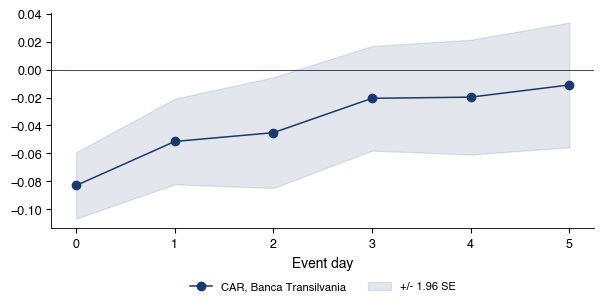

In [32]:
from scipy import stats
mkt = fetch_daily('BET', 'market', 'close', start='2017-01-01')
def event(name):
    r = np.log(pd.concat([load(name, start='2017-01-01'), mkt], axis=1, keys=['i', 'm']).dropna()).diff().dropna()
    t0 = r.index.get_loc(pd.Timestamp('2018-12-19')); est, ev = r.iloc[t0 - 250:t0 - 10], r.iloc[t0:t0 + 6]
    X = np.column_stack([np.ones(len(est)), est['m']]); b = np.linalg.lstsq(X, est['i'], rcond=None)[0]
    sig = (est['i'] - X @ b).std(ddof=2); pred = b[0] + b[1] * ev['m']; ar = ev['i'] - pred; L, T = len(ar), len(est)
    mb, Smm = est['m'].mean(), ((est['m'] - est['m'].mean()) ** 2).sum()
    se0 = sig * np.sqrt(1 + 1 / T + (ev['m'].iloc[0] - mb) ** 2 / Smm)          # prediction-error variances (MacKinlay, 1997)
    seC = sig * np.sqrt(L + L ** 2 / T + (ev['m'].sum() - L * mb) ** 2 / Smm)
    pv = lambda z: 2 * stats.t.sf(abs(z), T - 2)
    print(f'{name}: estimation window {est.index[0].date()} - {est.index[-1].date()} (T = {T}); a = {b[0]:.4%} a day, b = {b[1]:.3f}, '
          f'sigma_e = {sig:.3%}, mean r_m = {mb:.3%}, S_mm = {Smm:.5f}')
    tab = pd.DataFrame({'r_i': ev['i'], 'r_m': ev['m'], 'predicted': pred, 'AR': ar}); tab.index = [f'{k} ({d.date()})' for k, d in enumerate(ev.index)]
    print((100 * tab).round(2).to_string(), f'\nCAR[0,+5] = {ar.sum():.2%}')
    print(f'AR_0: leverage (r_m0 - mean)^2/S_mm = {(ev["m"].iloc[0] - mb) ** 2 / Smm:.3f}, SE {se0:.2%}, t = {ar.iloc[0] / se0:.2f}, p = {pv(ar.iloc[0] / se0):.1e}; '
          f'CAR: SE {seC:.2%}, t = {ar.sum() / seC:.2f}, p = {pv(ar.sum() / seC):.2f}')
    print(f'as price changes: r_i day 0 {np.expm1(ev["i"].iloc[0]):.2%}, BET {np.expm1(ev["m"].iloc[0]):.2%}, AR_0 as a price relative {np.expm1(ar.iloc[0]):.2%}')
    return ar, sig, T, L, mb, Smm, ev
ar, sig, T, L, mb, Smm, ev = event('Banca Transilvania')
se_path = [sig * np.sqrt(l + l ** 2 / T + (ev['m'].iloc[:l].sum() - l * mb) ** 2 / Smm) for l in range(1, L + 1)]
car = np.cumsum(ar.values); fig, ax = plt.subplots(figsize=(7, 2.8))
ax.plot(range(6), car, 'o-', color=MainBlue, label='CAR, Banca Transilvania')
ax.fill_between(range(6), car - 1.96 * np.array(se_path), car + 1.96 * np.array(se_path), color=MainBlue, alpha=0.12, label='+/- 1.96 SE')
ax.axhline(0, color=Gray, lw=0.6); ax.set_xlabel('Event day'); legend_outside_bottom(ax, ncol=2, y=-0.2); plt.show()

**Interpretation (solution).** Day 0 is a large surprise, but the ARs of days 1–3 reverse most of it: the six-day CAR is not significant. BET fell 11.2% (log return −11.9%): the market model removes most of the shock, so the AR (−8.3% in log terms, about −8.0% as a price relative) is market-relative, not the bank's total price loss of 19.9% (log −22.2%); a benchmark without banks would avoid this contamination. With one or six non-Normal errors the $t$ reference is approximate.

### B8 [Proposed]. The same event for BRD <a id="B8"></a>

**Model:** B7 [Solved]; reuse its function, only the symbol changes. **Data:** BRD (adjusted close) and the BET index; same windows as B7.

1. Report $\hat b$, $\hat\sigma_\varepsilon$, the AR table and $CAR[0,+5]$ with $t$ and $p$.
2. Build a two-bank table: $AR_0$, its prediction-error $t$, $CAR$ and its $t$.
3. Plot the two CAR paths with ±1.96 SE bands on one chart.
4. Which bank was hit harder relative to its normal volatility? Use the prediction-error $t$ of $AR_0$ as the comparison statistic.

**Interpretation.** The reversal can mean overreaction or a partly withdrawn policy; what dated evidence would separate the two?

In [33]:
# Your code here

### B9 [Proposed]. BET-TR in RON and in EUR <a id="B9"></a>

**Model:** B2 [Solved] (currency conversion). **Data:** the BET-TR index (close) and BNR EUR/RON $S_t$ (RON per EUR), prices joined on common days, 5 Jan 2015 – 18 Sep 2026.

1. Convert: $P^{EUR}_t = P^{RON}_t/S_t$; work one date step by step (13 Aug 2025).
2. Show $r^{EUR}_t = r^{RON}_t - \Delta s_t$, with $s_t = \ln S_t$.
3. Compute the CAGR and the volatility (observed $q = n/Y$ of the joined prices) in RON and in EUR, and the correlation of $r^{RON}$ with $\Delta s$.
4. Plot both wealth paths.

**Report:** the two CAGRs, two volatilities, the correlation, the chart. **Interpretation:** for a euro investor, is the leu's depreciation a return drag, a risk, or both?

In [34]:
# Your code here

### B9 extended [Proposed]. Is the currency effect significant? <a id="B9x"></a>

**Model:** B2 extended and B7 [Solved]. **Data:** B9, $n = 2925$ common-day returns, $q = n/Y$ observed intervals a year from the joined prices of B9.

1. Show $\operatorname{Var}(r^{EUR}) = \operatorname{Var}(r^{RON}) + \operatorname{Var}(\Delta s) - 2\operatorname{Cov}(r^{RON}, \Delta s)$; report each term annualised (×$q$) in decimal units, then take square roots.
2. Regress $r^{RON}_t$ on a constant and $\Delta s_t$ with Newey–West HAC standard errors (Newey and West, 1987, $L = 8$); report the slope, $t$ and $p$; add a stationary-bootstrap 95% interval for the correlation (`default_rng(42)`).
3. Estimate the annual log drift of the leu, $q \times$ mean of $\Delta s_t$, with its HAC SE, $t$ and 95% interval.
4. Show that $\ln(1 + CAGR^{RON}) - \ln(1 + CAGR^{EUR}) = \ln(S_{end}/S_{start})/Y$, the drift of (3).

**Interpretation.** The hypothesis tested in (3) is "zero log drift".
- Is the gap between your two CAGRs of B9 distinguishable from zero?
- Would a euro investor hedge the leu?

In [35]:
# Your code here

### B1 extended [Proposed]. The standard Hampel filter <a id="B1x"></a>

**Model:** B1 full audit [Solved]. **Method:** standard Hampel filter, [Pearson, Neuvo, Astola and Gabbouj (2016)](https://doi.org/10.1186/s13634-016-0383-6), Section 2, eqs. (1)–(4): window $x_{k-K}, \dots, x_{k+K}$ with $K = 5$ (11 quotes, as in their Sections 5–6); $m_k$ = window median, $S_k = 1.4826 \times \operatorname{median}_j |x_{k-j} - m_k|$; $x_k$ is flagged if $|x_k - m_k| > t\,S_k$; the first and last 5 quotes are not tested. **Data:** BNR EUR/RON 2015–2026 (clean reference) and the weekday market series of B1 full audit.

1. Work the window around 13 Aug 2025 step by step: $m_k$, MAD, $S_k$ and $|x_k - m_k|/S_k$; for which $t$ is the quote flagged?
2. On BNR: share of implosion windows ($S_k = 0$, their Section 3) and share of days flagged on their grid $t = 0, 0.5, \dots, 21$ (Section 5.2), with a plot; compare the bound of their eq. (8) with the largest $|x_k - m_k|/S_k$.
3. On the market series, apply $t = 2$ (their Section 6) and $t = 5$ (their Section 5.2): flags, overlap with the 11 flags and 9 errors of B1 full audit, volatility after removing the flags.

**Interpretation.**
- Why MAD, and why 1.4826?
- What happens in an implosion window?
- Can a threshold replace the BNR check of B1?

In [36]:
# Your code here

## Pack 7: Stablecoins <a id="pack7"></a>

B10, B10 extended. Prerequisites: A2–A3, B7.

### B10 [Proposed]. Stablecoin growth <a id="B10"></a>

**Model:** A2–A3 and B2 [Solved]. **Data:** DefiLlama, daily total circulating value of USD-pegged stablecoins, divided by $10^9$ (bn USD), 31 Dec 2019 – 18 Sep 2026.

1. Extract year-end values 2019–2025 and the calendar-year growth; report 2026 separately as year-to-date growth to 18 Sep.
2. Find the 2022 peak and the following trough up to the end of 2023, with dates, and the peak-to-trough change.
3. Compute the CAGR from 1 Jan 2020 to 18 Sep 2026 with the exact endpoints.
4. Plot the series with the year-end points.

**Interpretation.** Supply is a USD value in circulation, not a price; can it fall without any token being burned?

In [37]:
# Your code here

### B10 extended [Proposed]. Did the Terra collapse change the growth regime? <a id="B10x"></a>

**Model:** B7 [Solved] (OLS regression and its $t$ test). **Data:** $g_t = \Delta\ln(\text{supply}_t)$, 2 Jan 2020 – 18 Sep 2026, $n = 2452$; Terra collapse 9 May 2022.

1. Known date (Chow, 1960): $g_t = a + b\,D_t + e_t$, $D_t = 1\{t \ge \text{9 May 2022}\}$, HAC SE (Newey and West, 1987, $L = 8$); report $a$, $b$ (annualised ×365) and $t$.
2. Unknown date (Andrews, 1993): the HAC Wald statistic for every date in the central 70% (3 Jan 2021 – 15 Sep 2025); compare its maximum with 8.85, the 5% critical value for this trimming.
3. Least-squares date: the date minimising the sum of squared residuals; plot the Wald and SSR profiles.
4. Check the residual variance before and after the date, and say whether the break-date confidence interval of Bai (1997), which assumes the same error distribution in both regimes, can be reported.

**Interpretation.**
- Did the slowdown start with Terra?
- Is the break in the level or in the drift of supply?

In [38]:
# Your code here

## Pack 8: Passive investing lab <a id="pack8"></a>

C3. Prerequisites: the lecture case study, Pack 2.

### C3 [Proposed]. Passive investing and demand elasticity <a id="C3"></a>

**Model:** the lecture case study ([Haddad, Huebner and Loualiche, 2025](https://doi.org/10.1257/aer.20230505)) and B2 extended [Solved]. **Question:** is the one-third pass-through of the paper robust to who turns passive?

**Notation.** Stock $k$, active investor $i$; $w_{ik}$ = shares held by $i$ as a fraction of all shares of $k$; active share $A_k = \sum_i w_{ik}$; own elasticity $\bar{\mathcal{E}}_{ik}$; $\chi$: strength of the strategic response, how much investors' demand reacts to the elasticity of the other investors in the stock (Table 2, row 1: $\chi = 2.97$); aggregate elasticity (footnote 53) $\mathcal{E}_{agg,k} = \sum_i w_{ik}\bar{\mathcal{E}}_{ik}/(1 + \chi A_k)$.

**Two-investor warm-up:** $w_1 = 0.4$ with $\bar{\mathcal{E}}_1 = 1$, $w_2 = 0.3$ with $\bar{\mathcal{E}}_2 = 3$, $\chi = 2.97$; 0.1 of the shares turn passive.
1. Compute $\mathcal{E}_{agg}$ before, and after the switch when both reduce in proportion, when investor 2 (elastic) switches, when investor 1 switches.
2. Compare each $\Delta\log\mathcal{E}_{agg}/\Delta\log A$ with $1/(1 + \chi A) = 0.325$.

**Data:** FRED `BOGZ1LM563064100Q` (ETF corporate equities) over `BOGZ1LM893064105Q` (all sectors), 2001 Q1 – 2026 Q2.

3. ETF share in 2001 Q1, 2020 Q4, 2026 Q2 and the implied changes with 81% active in 2001 and pass-through 0.33.

**Simulation** (starter code below, `numpy.random.default_rng(seed)`):

4. 2,000 stocks: $A_k \sim U(0.55, 0.85)$; 40 active investors per stock with $w_{ik} = A_k \times$ weights drawn from the Dirichlet(1, …, 1) distribution (uniform on the 40-dimensional simplex); $\bar{\mathcal{E}}_{ik}$ log-Normal with median 1.6 and log standard deviation 0.6; $\chi = 2.97$.
5. In each stock a fraction $f_k \sim U(0, 0.2)$ of $A_k$ turns passive under three rules: all in proportion; most elastic first; least elastic first (whole holdings in order, the last one partly, until $f_k A_k$ is reached).
6. Regress $\Delta\log\mathcal{E}_{agg,k}$ on a constant and $\Delta\log A_k$ (Table 4, column 1).
7. Repeat for seeds 1–10 with the same draws for all rules, and for $\chi = 0$.

**Report:** the ETF shares and implied changes; a table of slopes (mean, min, max over seeds) next to the mean of $1/(1 + \chi A_k)$. The seed range is simulation variability, not a sampling confidence interval. **Interpretation:**
- Why is the slope one-third only for representative switchers?
- How should the paper's 11% be read if the most elastic investors turned passive first?

In [39]:
def c3_run(seed, chi=2.97, K=2000, N=40, mode='rep'):
    """Simulated cross-section: K stocks, N active investors each; A_k = active share of stock k (fraction of all shares),
    w_ik = holdings of investor i in stock k as a fraction of all shares (sum_i w_ik = A_k),
    E_agg,k = sum_i w_ik Ebar_ik / (1 + chi A_k) (footnote 53); a fraction f_k of A_k turns passive under a rule."""
    rng = np.random.default_rng(seed)
    A = rng.uniform(0.55, 0.85, K); f = rng.uniform(0, 0.2, K)
    dlE, dlA, pt, E0s = np.empty(K), np.empty(K), np.empty(K), np.empty(K)
    for k in range(K):
        s = rng.dirichlet(np.ones(N)) * A[k]; e = np.exp(np.log(1.6) + 0.6 * rng.standard_normal(N))
        E0 = (s * e).sum() / (1 + chi * A[k]); target = f[k] * A[k]
        if mode == 'rep':
            sw = f[k] * s
        else:
            order = np.argsort(-e) if mode == 'high' else np.argsort(e)
            sw = np.zeros(N); rem = target
            for i in order:
                x = min(s[i], rem); sw[i] = x; rem -= x
                if rem <= 1e-15:
                    break
        A1 = A[k] - sw.sum(); E1 = ((s - sw) * e).sum() / (1 + chi * A1)
        dlE[k] = np.log(E1 / E0); dlA[k] = np.log(A1 / A[k]); pt[k] = 1 / (1 + chi * A[k]); E0s[k] = E0
    X = np.c_[np.ones(K), dlA]; b = np.linalg.lstsq(X, dlE, rcond=None)[0]
    return b[1], pt.mean(), E0s.mean()

In [40]:
# Your code here